## This is where the cool stuff happends
Currently using a conda environment based on lukas_fysstk.yaml, but also works with *add other envs*.

In [21]:
### imports
# basics
import numpy as np
import matplotlib.pyplot as plt

# scikit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils import resample


### recurring functions and helpers
#Function for OLS through SVD
def ols(X, y):
    """Ordinary least squares through the SVD.
       provided by: https://github.com/EducationalMaterialUiO/MachineLearningUiO/"""
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    return Vt.T @ (U.T @ y / s)

def runge(x):
    """Runge function, given in task description."""
    return 1.0 / (1.0 + 25.0 * x**2)

def design_matrix(x, degree, intercept=True):
    """creates design matrix for polynomial regression of given degree and intercept option.
       given in task description."""
    # polynomial features [1, x, x^2, ..., x^degree] (drop the 1 if intercept=False)
    start = 0 if intercept else 1
    return np.vstack([x**p for p in range(start, degree + 1)]).T

def MSE(y_data, y_model):
    """from Tuesday lecture week 35"""
    return np.mean((y_data - y_model) ** 2)

def R2(y_data, y_model):
    """from Tuesday lecture week 35"""
    return 1.0 - np.sum((y_data - y_model) ** 2) / np.sum((y_data - np.mean(y_data)) ** 2)

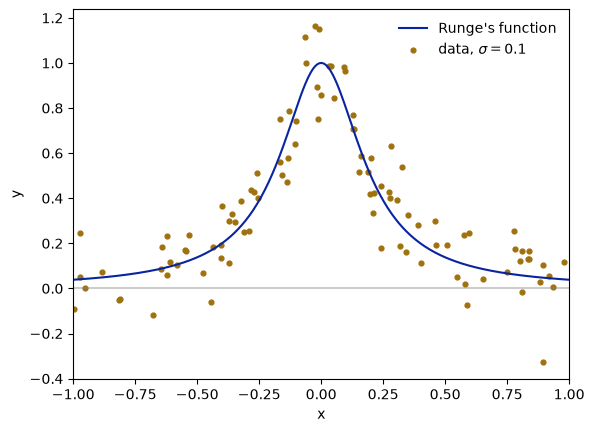

In [58]:
### Generate data and create quicklook
def generate_data(n=100, sigma=0.1, seed=2026):
    rng = np.random.default_rng(seed)     
    x = np.sort(rng.uniform(-1, 1, n))
    y = runge(x) + rng.normal(0, sigma, n)
    return x, y, n, sigma

x, y, n, sigma = generate_data()

train_color = "#32A911"
test_color = "#048582"

xx = np.linspace(-1, 1, 400)
plt.plot(xx, runge(xx), color="#0824A0", label="Runge's function")
plt.scatter(x, y, s=12, color="#A0720E", label=rf"data, $\sigma={sigma}$")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(frameon=False)
plt.xlim(-1,1)
plt.plot([-1,1], [0,0], color='grey', linestyle='-', alpha=0.4)
plt.show()

# Notes
- Introduction
- design

## Part a): Ordinary Least Squares (OLS) for the Runge function
- OLS regression analysis using polynomials up to order 15
- explore dependence on number of data points
- and polynomial degree
- using MSE and R2

Plots:
- theta for increasing polynomial
- metrics as function of polynomial degree

Components:
- train-test split
- scaling/centering of data

C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\3220529146.py:52: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[0].plot(xx,mse_train,"b*-",label="Training", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\3220529146.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r*-" (-> color='r'). The keyword argument will take precedence.
  ax[0].plot(xx,mse_test,"r*-",label="Test", color=test_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\3220529146.py:59: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[1].plot(xx,r2_train,"b*-",label="Training", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\3220529146.py:60: UserWarning: color is redundantly defined by t

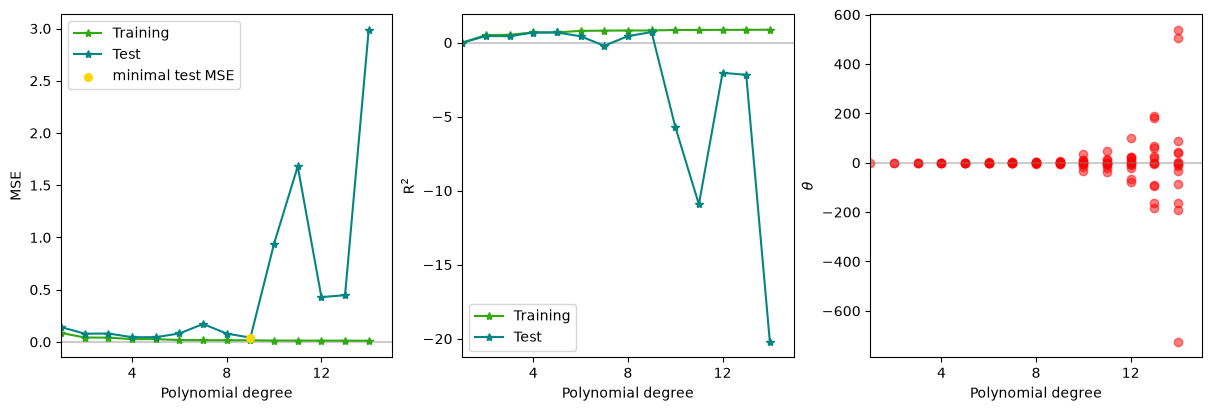

In [67]:
# Splitting data into test and train data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,random_state=2026)

### collector function
def prepare_design_matrix(x_train, x_test, y_train, y_test, degree=5, intercept=True):
    """prepares design matrix and scales data"""
    # create design matrix
    X_train = design_matrix(x_train, degree=degree, intercept=intercept)
    X_test = design_matrix(x_test, degree=degree, intercept=intercept)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)
    return X_train_norm, X_test_norm, y_train_norm, y_test_norm

#Adding a model to perform OLS for polynomials up to degree 15
mse_train = []
mse_test = []
r2_train = []
r2_test = []
save_theta = []
for d in range(1,15):
    #Design matrix on the training data:
    X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    #calculate OLS theta
    theta = ols(X_train,y_train)
    save_theta.append(theta)

    #Calculate the MSE:
    mse_train.append(mean_squared_error(y_train, X_train @ theta))
    mse_test.append(mean_squared_error(y_test,  X_test @ theta))
    r2_train.append(r2_score(y_train, X_train @ theta))
    r2_test.append(r2_score(y_test,  X_test @ theta))


#Plotting the MSE as a function of polynomial degree
xx = np.linspace(1,14,14)

fig, ax = plt.subplots(1,3,figsize=(12,4), constrained_layout=True)

for a in ax:
    # a.grid()    
    a.set_xticks(np.arange(0,16,4))
    a.set_xlim(1,15)
    # a.set_yscale('log')
    a.hlines(0,16,0, color='grey', alpha=0.4)


ax[0].plot(xx,mse_train,"b*-",label="Training", color=train_color)
ax[0].plot(xx,mse_test,"r*-",label="Test", color=test_color)
ax[0].set_ylabel("MSE")
ax[0].set_xlabel("Polynomial degree")
ax[0].scatter(xx[np.argmin(mse_test)], np.min(mse_test), color='gold', marker='o', s=30, zorder=5, label='minimal test MSE')
ax[0].legend()

ax[1].plot(xx,r2_train,"b*-",label="Training", color=train_color)
ax[1].plot(xx,r2_test,"r*-",label="Test", color=test_color)
ax[1].set_ylabel("R$^2$")
ax[1].set_xlabel("Polynomial degree")
ax[1].legend()
# ax[1].set_ylim([1e-9, 1e0])

for i in range(len(save_theta)):
    ax[2].scatter(np.full(i+1, xx[i]), save_theta[i], color='r', alpha=0.5)
# ax[2].plot(xx,save_theta,"r*-",label="Test")
ax[2].set_ylabel(r"$\theta$")
ax[2].set_xlabel("Polynomial degree")


plt.show()


# Notes
- no clear minimum in MSE (added to plot)
- style whole numbers
- although 9 is best in MSE, degree 5 would be the best choice as it only differs in the third decimal, has a lower R2 and is computationally more efficient
- is theta the reason for the metrics going crazy above 9?

## Part b): Adding Ridge regression for the Runge function
- same analysis as a, but with Ridge
- for different values of penalty parameter lambda

Polynomial degree: 1
Minimum MSE is  0.0852454331582845 at lambda = 2.5118864315095823e-07 for training data
Minimum MSE is  0.1408697620662985 at lambda = 10000.0 for test data
Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 3
Minimum MSE is  0.0403968803604171 at lambda = 6.30957344480193e-08 for training data
Minimum MSE is  0.0798943307575858 at lambda = 1.5848931924611174 for test data
Polynomial degree: 4
Minimum MSE is  0.026497232884738663 at lambda = 1e-08 for training data
Minimum MSE is  0.04509426766896332 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at l

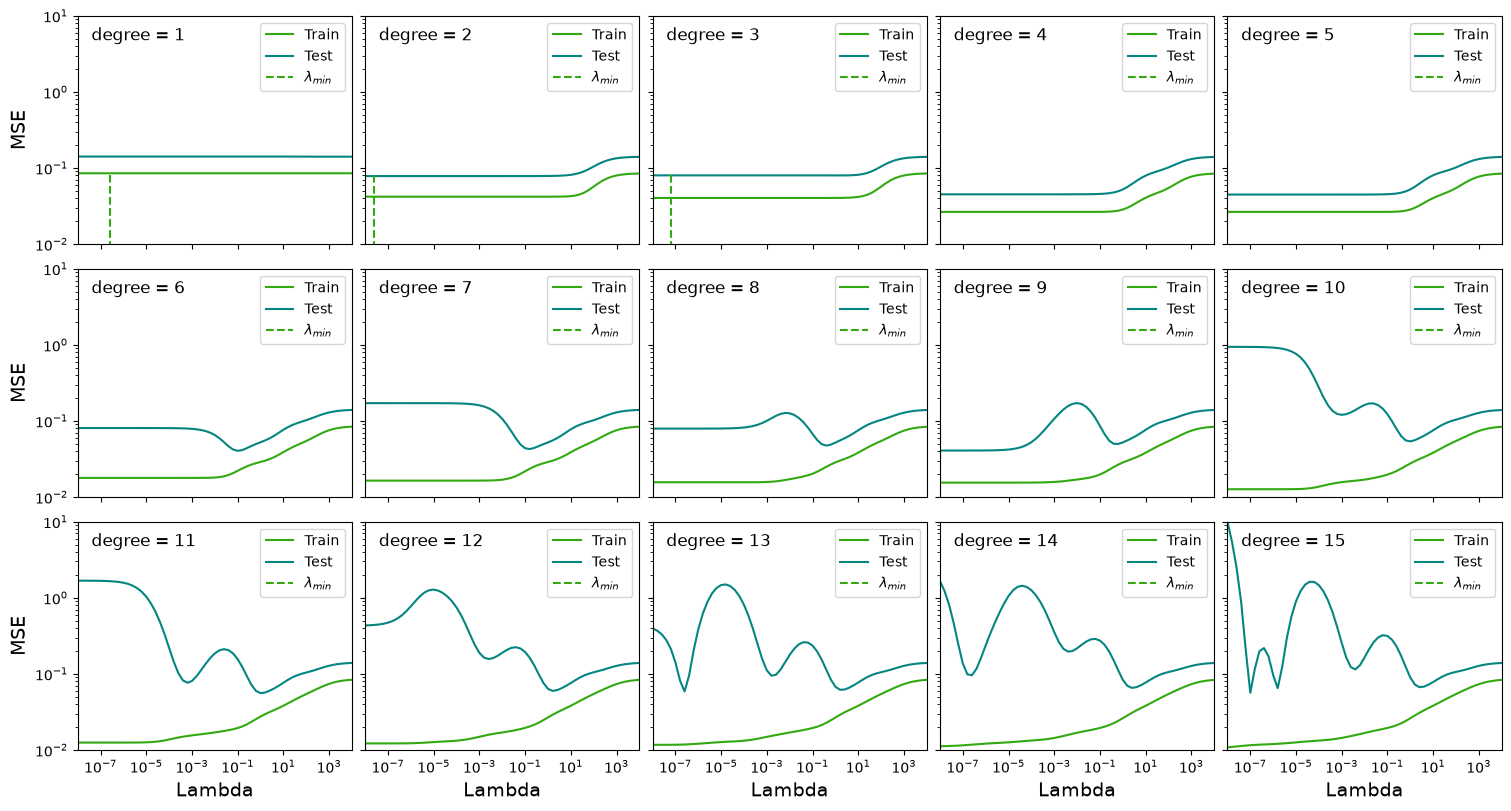

Polynomial degree: 2
Minimum MSE is  0.0419864756226363 at lambda = 2.511886431509582e-08 for training data
Minimum MSE is  0.07832073165244044 at lambda = 1e-08 for test data
Polynomial degree: 5
Minimum MSE is  0.026493143402373014 at lambda = 1e-08 for training data
Minimum MSE is  0.044767790791748426 at lambda = 1e-08 for test data
Polynomial degree: 6
Minimum MSE is  0.017829076450046364 at lambda = 1e-08 for training data
Minimum MSE is  0.04047207755781056 at lambda = 0.1 for test data
Polynomial degree: 15
Minimum MSE is  0.010797727052551677 at lambda = 1e-08 for training data
Minimum MSE is  0.056442377861310566 at lambda = 1e-07 for test data


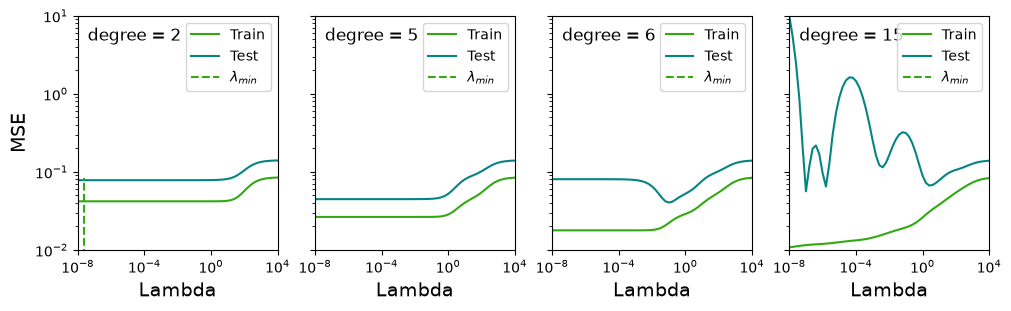

In [65]:
#Adding a model to perform OLS for polynomials up to degree 15
degs = np.arange(1,16)
fig = plt.figure(figsize=(15,8), constrained_layout=True)
axes=[]
# plot all of the panels here first
for d in degs:
    ax = fig.add_subplot(3,5,d, sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="Train", color=train_color)
    ax.plot(lambdas,mse_test,label="Test", color=test_color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE", fontsize=14)
    ax.set_xlabel("Lambda", fontsize=14)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xlim(1e-8, 1e4)
    ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--",  label=r'$\lambda_{min}$', color=train_color)
    ax.legend()
    ax.label_outer()
    ax.text(0.05, 0.95, f"degree = {d}", transform=ax.transAxes, ha="left", va="top", fontsize=12)


    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")
plt.show()

# not plot selected subset of panels
fig = plt.figure(figsize=(10,3), constrained_layout=True)
count=0
axes = []
for d in [2,5,6,15]:
    count+=1
    ax = fig.add_subplot(1,4,count, sharex=axes[0] if axes else None, sharey=axes[0] if axes else None)
    axes.append(ax)
    #Design matrix on the training data:
    # X_train, X_test, y_train, y_test = prepare_design_matrix(x_train, x_test, y_train, y_test, degree=d, intercept=False)

    X_train = design_matrix(x_train, degree=d, intercept=False)
    X_test = design_matrix(x_test, degree=d, intercept=False)

    # centering data by mean and scaling data by standard deviation
    X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
    X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
    y_train_norm = y_train - np.mean(y_train)
    y_test_norm = y_test - np.mean(y_test)

    #Loop through different lambdas and calculate the Ridge regression and MSE
    lambdas = np.logspace(-8, 4, 61)
    mse_train = []
    mse_test = []
    for l in lambdas:
        #Theta from Ridge
        theta = Ridge(alpha=l, fit_intercept=False).fit(X_train_norm, y_train_norm).coef_
        #MSE for train and test data
        mse_train.append(mean_squared_error(y_train_norm, np.mean(y_test) + X_train_norm @ theta))
        mse_test.append(mean_squared_error(y_test_norm,  np.mean(y_test) + X_test_norm @ theta))


    #Plot the results
    ax.plot(lambdas,mse_train,label="Train", color=train_color)
    ax.plot(lambdas,mse_test,label="Test", color=test_color)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_ylabel("MSE", fontsize=14)
    ax.set_xlabel("Lambda", fontsize=14)
    ax.set_ylim(1e-2, 1e1)
    ax.set_xlim(1e-8, 1e4)
    ax.vlines(lambdas[np.argmin(mse_train)],ymin=0,ymax=np.max(mse_train),linestyle="--", label=r'$\lambda_{min}$', color=train_color)    
    ax.legend()
    ax.label_outer()
    ax.text(0.05, 0.95, f"degree = {d}", transform=ax.transAxes, ha="left", va="top", fontsize=12)

    #Finding the minimum MSE and at what lambda
    print(f"Polynomial degree: {d}")
    print("Minimum MSE is ",np.min(mse_train), "at lambda =", lambdas[np.argmin(mse_train)], "for training data")
    print("Minimum MSE is ",np.min(mse_test), "at lambda =", lambdas[np.argmin(mse_test)], "for test data")
plt.show()

# Notes
Task: Perform the same analysis as you did in the previous part but now for different values of the
penalty parameter λ. Compare and analyze your results with those obtained in part a) with the
OLS method. Study the dependence on λ, and connect what you see to the shrinkage of the
singular-value modes discussed in the lectures


- select a few examples and put rest in appendix (2,5,6 and 15) put some titles in there and get same y axis
- 5 -> 6 is first significant change (and 5 should be the optimal one in OLS) 
    this is the interesting part
- 1 is bad ofc, so obvious we don't need it.
- high complexity for 10 and 15 (doesn't even make a big change anymore)
- anything else to discuss?
   6 has a much higher MSE overall (5 better for Ridge)
   9 randomly low MSE (similar to OLS), but it also has a weird peak 
   higher orders than 9 all have large MSE
   

lambda sensitivity/slope of training set changes with degree (flatter slope) and for positive lambda, the training and test MSE have the same slopes, because it's definetely not good, if the training MSE is large for high lambdas

it shrinks the wrong thetas too much for some lambdas
that's why the MSE increases (the cost function is too effective)


### Part c): The bias-variance tradeoff and the bootstrap

C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\762280785.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\762280785.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r*-" (-> color='r'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_test,"r*-",label="Test", color=test_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\762280785.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b*-" (-> color='b'). The keyword argument will take precedence.
  ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\762280785.py:29: UserWarning: color is redundantly defined by the 'color

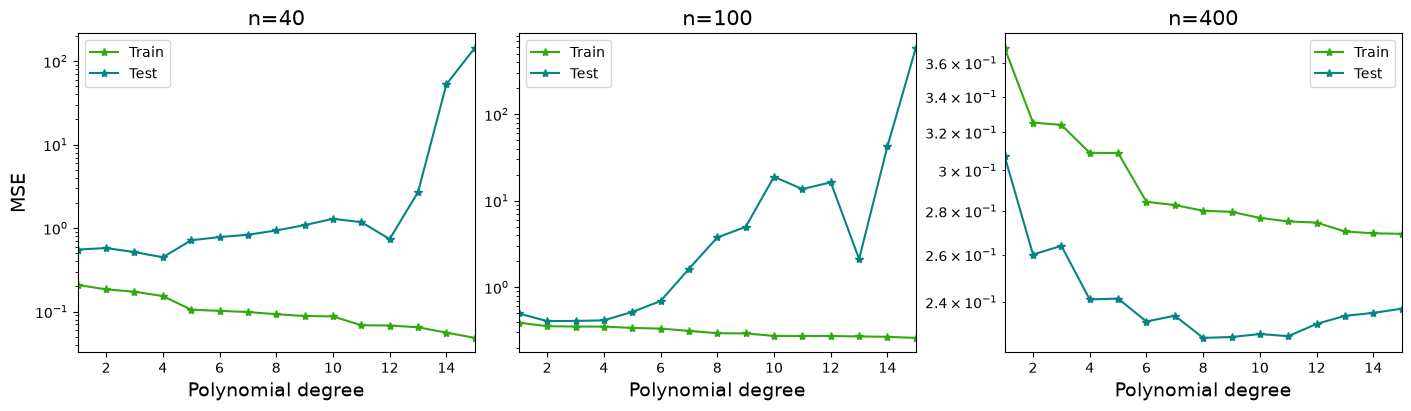

In [70]:
# Your code for part c) heret
### Inspired by figure 2.11 in Hastie et al., 2009

max_deg = 15
fig, ax = plt.subplots(1,3,figsize=(14,4), sharey=False, constrained_layout=True)
for n, i in zip((40, 100, 400), (0,1,2)):
    # get some new data (but different names to not overwrite the ones used consistently)
    x_c, y_c, n_c, sigma_c = generate_data(n=n, sigma=0.5)
    x_train_c, x_test_c, y_train_c, y_test_c = train_test_split(x_c, y_c, test_size=0.3,random_state=2026)

    #Adding a model to perform OLS for polynomials up to degree 15
    mse_train = []
    mse_test = []
    for d in range(1,max_deg+1):
        X_train_c, X_test_c, y_train_c, y_test_c = prepare_design_matrix(x_train_c, x_test_c, y_train_c, y_test_c, degree=d, intercept=False)
        
        #calculate OLS theta
        theta = ols(X_train_c,y_train_c)

        #Calculate the MSE:
        mse_train.append(mean_squared_error(y_train_c, X_train_c @ theta))
        mse_test.append(mean_squared_error(y_test_c,  X_test_c @ theta))


    #Plotting the MSE as a function of polynomial degree
    xx = np.linspace(1,max_deg,max_deg)

    ax[i].plot(xx,mse_train,"b*-",label="Train", color=train_color)
    ax[i].plot(xx,mse_test,"r*-",label="Test", color=test_color)
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"n={n}", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(1,15)
ax[0].set_ylabel("MSE", fontsize=14)


plt.show()

# Notes
- this is similar to the Hastie et al. Fig. 2.11
- 

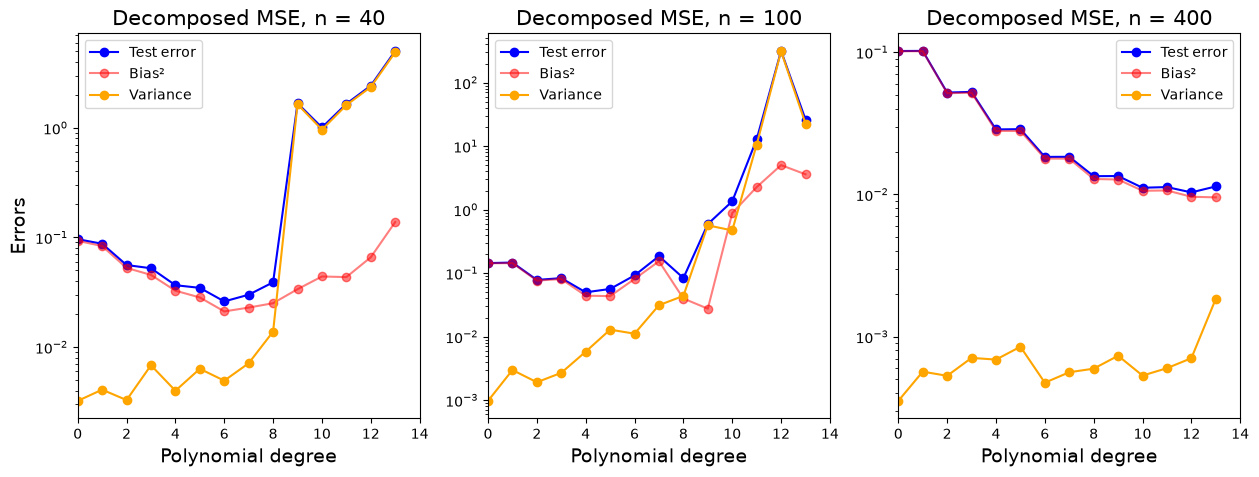

In [73]:
n_bootstraps = 100 #100 resamples of training data
degree_max = 14 #13 + 1

def bootstrap_polynomial(n, degree_max, sigma=0.1, seed=2026, n_bootstraps=n_bootstraps):
    x, y, _, _ = generate_data(n=n, sigma=sigma, seed=seed)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=seed)

    x_train = x_train.reshape(-1, 1)
    x_test = x_test.reshape(-1, 1)
    y_test = y_test.reshape(-1, 1)

    error = np.zeros(degree_max)
    bias = np.zeros(degree_max)
    variance = np.zeros(degree_max)

    for degree in range(degree_max):
        model = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()

        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))

    return error, bias, variance
    

fig, ax = plt.subplots(1,3,figsize=[15,5])
sp = 0 #What subplot / axis to plot

for n in (40, 100, 400): #40,100,400
    error, bias, variance = bootstrap_polynomial(n=n, degree_max=degree_max)

    #Plot results
    ax[sp].plot(range(degree_max),error,"o-",color="blue",label="Test error")
    ax[sp].plot(range(degree_max),bias,"o-",color="red", label="Bias²", alpha=0.5)
    ax[sp].plot(range(degree_max),variance,"o-",color="orange",label="Variance")
    ax[sp].set_title(f"Decomposed MSE, n = {n}", fontsize=15)
    ax[sp].set_xlabel("Polynomial degree", fontsize=14)
    
    # ax[sp].set_ylim(1e-4,2e3)
    ax[sp].set_yscale("log")
    ax[sp].set_xlim(0,14)
    ax[sp].legend()
    sp += 1
ax[0].set_ylabel("Errors", fontsize=14)
plt.show()


# Notes
- optimal at 4-5 for n=100
- large n is good, because the variance error becomes constant and less of trade off

In [27]:
#Replacing OLS by Ridge regression at fixed degree 12
def bias_variance_sweep(n=40, noise=0.1, maxdegree=14, n_bootstraps=100,
                        make_model=None, seed=2026):
    """Bootstrap estimate of error/bias^2/variance vs polynomial degree."""
    if make_model is None:
        make_model = lambda deg: make_pipeline(
            PolynomialFeatures(degree=deg), LinearRegression(fit_intercept=False))
    np.random.seed(seed)
    x = np.linspace(-3, 3, n).reshape(-1, 1)
    y = np.exp(-x**2) + 1.5 * np.exp(-(x - 2)**2) + np.random.normal(0, noise, x.shape)
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2,
                                                        random_state=seed)
    error, bias, variance = (np.zeros(maxdegree) for _ in range(3))
    for degree in range(maxdegree):
        model = make_model(degree)
        y_pred = np.empty((y_test.shape[0], n_bootstraps))
        for i in range(n_bootstraps):
            x_, y_ = resample(x_train, y_train)
            y_pred[:, i] = model.fit(x_, y_).predict(x_test).ravel()
        error[degree] = np.mean(np.mean((y_test - y_pred)**2, axis=1, keepdims=True))
        bias[degree] = np.mean((y_test - np.mean(y_pred, axis=1, keepdims=True))**2)
        variance[degree] = np.mean(np.var(y_pred, axis=1, keepdims=True))
    return error, bias, variance



degree_fixed = 12
lams = [0.0, 1e-4, 1e-1, 10.0]

print(f"degree {degree_fixed}, n = 40, 100 bootstraps")
print(f"{'lambda':>8}  {'error':>10}  {'bias^2':>10}  {'variance':>10}")
for lam in lams:
    if lam == 0.0:
        mk = lambda deg: make_pipeline(PolynomialFeatures(degree=deg),
                                       LinearRegression(fit_intercept=False))
    else:
        mk = lambda deg, lam=lam: make_pipeline(PolynomialFeatures(degree=deg),
                                                StandardScaler(),
                                                Ridge(alpha=lam))
    err, b2, var = bias_variance_sweep(n=40, maxdegree=degree_fixed + 1,
                                       make_model=mk)
    
    d = degree_fixed
    label = "OLS" if lam == 0.0 else f"{lam:g}"
    print(f"{label:>8}  {err[d]:10.4f}  {b2[d]:10.4f}  {var[d]:10.4f}")
    

degree 12, n = 40, 100 bootstraps
  lambda       error      bias^2    variance
     OLS      0.0762      0.0284      0.0478
  0.0001      0.0338      0.0272      0.0067
     0.1      0.0289      0.0228      0.0060
      10      0.1020      0.0979      0.0041


# Notes
- 0.1 is consistently one of the lowest errors
- OLS is much worse on everything else than bias (why bias: it's all just from test-training split)

## Part d): Cross-validation as a resampling technique

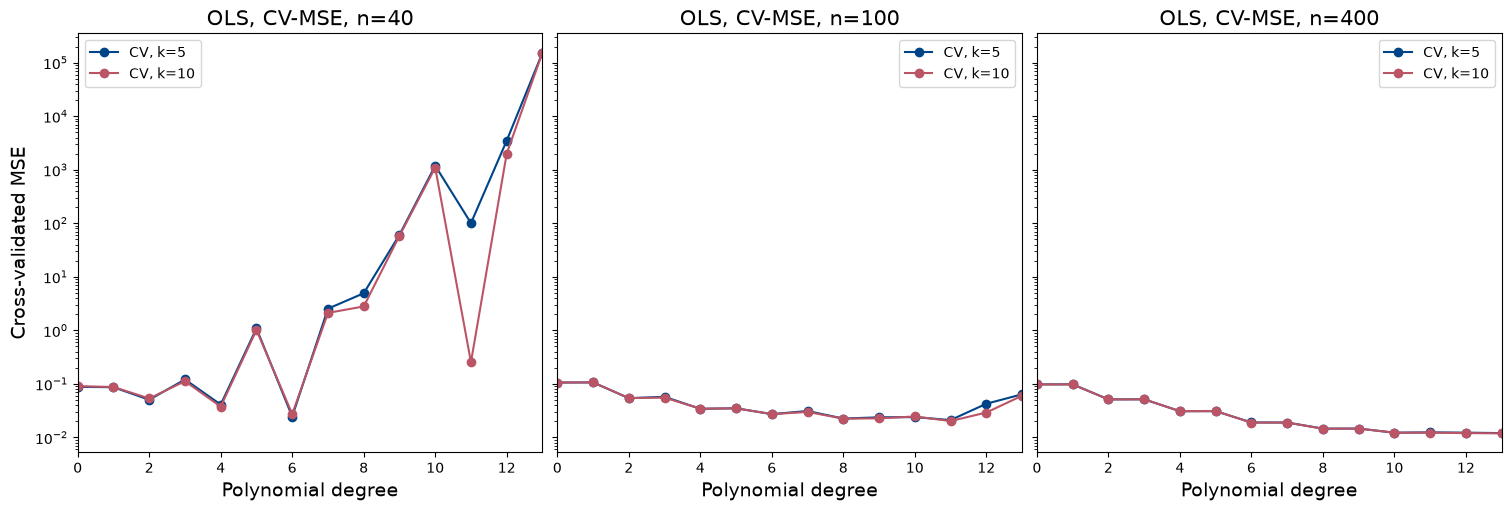

In [72]:
# Use the k-fold cross-validation functionality of Scikit-Learn (KFold together with cross_val_score,
# or cross_validate) and evaluate again the MSE function resulting from the test folds, for the
# OLS analysis of parts a) and c) as a function of the polynomial degree, 

from sklearn.model_selection import KFold, cross_val_score

def cv_mse_ols(x, y, degree_max, k, seed=2026):
    """k-fold CV MSE for OLS, as a function of polynomial degree."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse = np.zeros(degree_max)
    for degree in range(degree_max):
        pipe = make_pipeline(PolynomialFeatures(degree=degree),
                              LinearRegression(fit_intercept=False))
        scores = -cross_val_score(pipe, x, y, cv=kf,
                                   scoring="neg_mean_squared_error")
        mse[degree] = scores.mean()
    return mse

# Same n-values as the bootstrap sweep in part c)
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, constrained_layout=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10 = cv_mse_ols(x_cv, y_cv, degree_max, k=10)

    ax[i].plot(range(degree_max), mse_k5,  "o-", color="#004488", label="CV, k=5")
    ax[i].plot(range(degree_max), mse_k10, "o-", color="#BB5566", label="CV, k=10")
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"OLS, CV-MSE, n={n}", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(0,13)

ax[0].set_ylabel("Cross-validated MSE", fontsize=14)
plt.show()

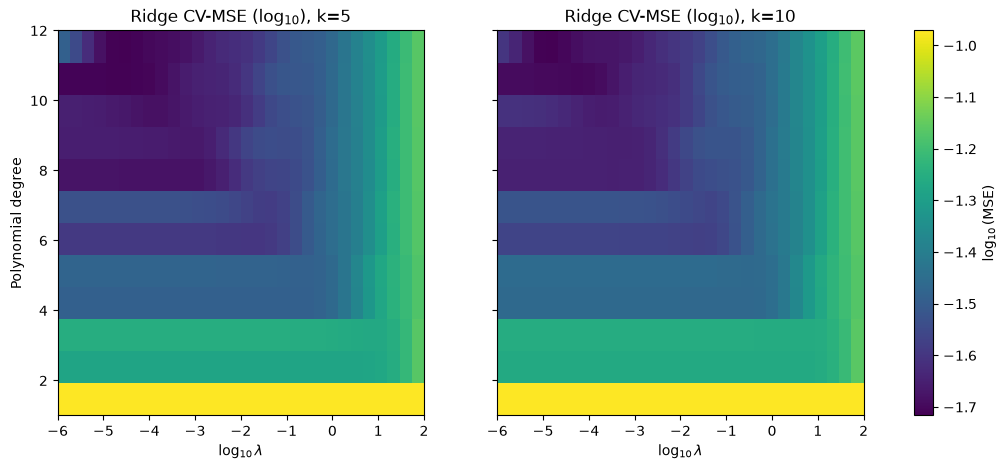

k=5: best degree=12, best lambda=2.395e-05, CV-MSE=0.02073
k=10: best degree=12, best lambda=1.269e-05, CV-MSE=0.01921


In [29]:
# and for Ridge regression
# as a function of both the polynomial degree and λ.

def cv_mse_ridge_grid(x, y, degrees, lambdas, k, seed=2026):
    """k-fold CV MSE for Ridge over a (degree, lambda) grid."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    mse_grid = np.zeros((len(degrees), len(lambdas)))
    for i, degree in enumerate(degrees):
        for j, lmb in enumerate(lambdas):
            pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                  StandardScaler(),
                                  Ridge(alpha=lmb))
            scores = -cross_val_score(pipe, x, y, cv=kf,
                                       scoring="neg_mean_squared_error")
            mse_grid[i, j] = scores.mean()
    return mse_grid

n_ridge = 100
x_r, y_r, _, _ = generate_data(n=n_ridge, sigma=0.1, seed=2026)
x_r = x_r.reshape(-1, 1)

degrees_ridge = list(range(1, 13))
lambdas = np.logspace(-6, 2, 30)

mse_ridge_k5  = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=5)
mse_ridge_k10 = cv_mse_ridge_grid(x_r, y_r, degrees_ridge, lambdas, k=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, grid, k in zip(axes, (mse_ridge_k5, mse_ridge_k10), (5, 10)):
    im = ax.imshow(np.log10(grid), aspect="auto", origin="lower",
                    extent=[np.log10(lambdas[0]), np.log10(lambdas[-1]),
                            degrees_ridge[0], degrees_ridge[-1]])
    ax.set_xlabel(r"$\log_{10}\lambda$")
    ax.set_title(f"Ridge CV-MSE (log$_{{10}}$), k={k}")
axes[0].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=axes, label=r"$\log_{10}$(MSE)")
plt.show()

for grid, k in zip((mse_ridge_k5, mse_ridge_k10), (5, 10)):
    i_best, j_best = np.unravel_index(np.argmin(grid), grid.shape)
    print(f"k={k}: best degree={degrees_ridge[i_best]}, "
          f"best lambda={lambdas[j_best]:.4g}, CV-MSE={grid[i_best, j_best]:.5f}")

# Notes
- transition to writing axis labels in scientific sence with log scale and not plotting the log directly
- also change to pcolormesh
- cmrameri colormaps
- best values bright
- compare to b) Ridge results 
- but weird that the best are at high polynomial degrees

In [30]:
# Optionally, you can
# also write your own k-fold cross-validation code and check that it reproduces the Scikit-Learn
# results when the two use the same fold assignment

def my_kfold_ridge_mse(x, y, degree, lmb, k, seed=2026):
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    poly = PolynomialFeatures(degree=degree)
    fold_mse = np.zeros(k)
    for j, (train_idx, test_idx) in enumerate(kf.split(x)):
        x_train, y_train = x[train_idx], y[train_idx]
        x_test,  y_test  = x[test_idx],  y[test_idx]

        X_train = poly.fit_transform(x_train)
        X_test  = poly.transform(x_test)

        scaler = StandardScaler().fit(X_train)
        ridge = Ridge(alpha=lmb).fit(scaler.transform(X_train), y_train)

        y_pred = ridge.predict(scaler.transform(X_test))
        fold_mse[j] = np.mean((y_pred - y_test) ** 2)
    return fold_mse.mean()

# Sanity check against cross_val_score, at one (degree, lambda) point
degree_check, lmb_check, k_check = 6, 1.0, 5
mine = my_kfold_ridge_mse(x_r, y_r, degree_check, lmb_check, k_check)

kf = KFold(n_splits=k_check, shuffle=True, random_state=2026)
pipe = make_pipeline(PolynomialFeatures(degree=degree_check), StandardScaler(), Ridge(alpha=lmb_check))
sklearn_mse = -cross_val_score(pipe, x_r, y_r, cv=kf, scoring="neg_mean_squared_error").mean()

print(f"own loop: {mine:.6f}   sklearn: {sklearn_mse:.6f}")

own loop: 0.036699   sklearn: 0.036699


n=40: best degree — CV(k=5)=6, CV(k=10)=6, bootstrap=6
n=100: best degree — CV(k=5)=11, CV(k=10)=11, bootstrap=4
n=400: best degree — CV(k=5)=13, CV(k=10)=13, bootstrap=13


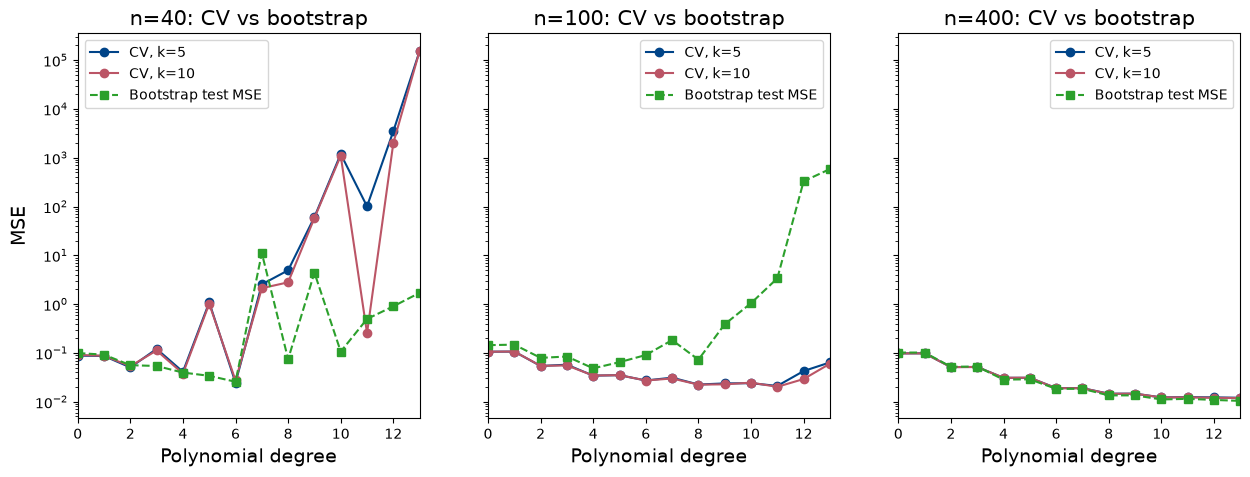

In [75]:
# Compare the MSE you get from cross-validation with the one you got from your bootstrap
# code in part c).

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for i, n in enumerate((40, 100, 400)):
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse_ols(x_cv, y_cv, degree_max, k=5)
    mse_k10 = cv_mse_ols(x_cv, y_cv, degree_max, k=10)
    error_boot, _, _ = bootstrap_polynomial(n=n, degree_max=degree_max)

    ax[i].plot(range(degree_max), mse_k5, "o-", label="CV, k=5", color="#004488")
    ax[i].plot(range(degree_max), mse_k10, "o-", label="CV, k=10", color="#BB5566")
    ax[i].plot(range(degree_max), error_boot, "s--", label="Bootstrap test MSE", color='tab:green')
    ax[i].set_yscale("log")
    ax[i].set_xlabel("Polynomial degree", fontsize=14)
    ax[i].set_title(f"n={n}: CV vs bootstrap", fontsize=15)
    ax[i].legend()
    ax[i].set_xlim(0,13)

    print(f"n={n}: best degree — CV(k=5)={np.argmin(mse_k5)}, "
          f"CV(k=10)={np.argmin(mse_k10)}, bootstrap={np.argmin(error_boot)}")

ax[0].set_ylabel("MSE", fontsize=14)
plt.show()

# Notes
- does how they work explain the difference between the methods

## Part e): Writing your own gradient descent code, with analytical gradients and automatic differentiation

Replace now the analytical expressions for the optimal parameters
$\boldsymbol{\theta}$ of OLS and Ridge regression with your own gradient descent
code. In this part we focus only on the simplest gradient descent approach with
a fixed learning rate $\eta$ (see the lectures and exercises of week 37 and
Sections 4.3–4.5 of the lecture notes),

$$
\boldsymbol{\theta}_{k+1} = \boldsymbol{\theta}_k - \eta\,\nabla_{\boldsymbol{\theta}}C(\boldsymbol{\theta}_k).
$$

Compute the gradient of the cost function in two independent ways:

1. **Analytically**, from the expressions you derived in the week-35 exercises,
   that is $\nabla_{\boldsymbol{\theta}}C = \frac{2}{n}\boldsymbol{X}^T(\boldsymbol{X}\boldsymbol{\theta}-\boldsymbol{y})$
   for OLS and the corresponding expression with the extra term
   $2\lambda\boldsymbol{\theta}$ for Ridge (check your normalization
   conventions).
2. By **automatic differentiation** (Section 4.14 of the lecture notes), using
   for example **JAX** (`jax.grad`) or **Autograd**. Write the cost function as
   an ordinary Python function of $\boldsymbol{\theta}$ and let the library
   produce its gradient.

Verify that the two gradients agree to machine precision for OLS and Ridge, and
use both in your gradient descent code. Discuss briefly why automatic
differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost
function.

Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.

The cell below shows the minimal version of the automatic-differentiation check
with JAX (install with `pip install jax jaxlib`). Note the 64-bit switch: JAX
defaults to 32-bit floats, which would hide the "machine precision" agreement.

what:
- gradient descent code
- fixed learning rate
- analytical vs automatic differentiation
- GD vs CF comparison



In [32]:
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)   # 64-bit floats, as in numpy


#Functions: 
def cost_ols(theta, X, y):
    return jnp.mean((y - X @ theta)**2)

def cost_ridge(theta, X, y, lmbda):
    return jnp.mean((y - X @ theta)**2) + lmbda * jnp.sum(theta**2)




#Setting up the data
rng = np.random.default_rng(2026)     
degree = 5 
lmbda = 1e-2
X = design_matrix(x, degree)
theta0 = rng.normal(size=X.shape[1])

#Computing the gradients in two ways: analytically and by automatic differentiation

# gradients by automatic differentiation (with respect to argument 0 = theta)
grad_ols_ad = jax.grad(cost_ols)
grad_ridge_ad = jax.grad(cost_ridge)

# the same gradients by hand
grad_ols_analytic = 2.0 / len(y) * X.T @ (X @ theta0 - y)
grad_ridge_analytic = grad_ols_analytic + 2.0 * lmbda * theta0

# Verifying that the two graidents agree to maching precision for both OLS and Ridge:
print("OLS   max |AD - analytic| =", np.max(np.abs(grad_ols_ad(theta0, X, y) - grad_ols_analytic)))
print("Ridge max |AD - analytic| =", np.max(np.abs(grad_ridge_ad(theta0, X, y, lmbda) - grad_ridge_analytic)))

# the largest safe learning rate for plain gradient descent: eta < 2 / lambda_max(Hessian)
H = 2.0 / len(y) * X.T @ X
print("eta_max for OLS  =", 2.0 / np.linalg.eigvalsh(H).max())

OLS   max |AD - analytic| = 8.881784197001252e-16
Ridge max |AD - analytic| = 8.881784197001252e-16
eta_max for OLS  = 0.8937721839600538


!! Discuss briefly why automatic differentiation is neither symbolic nor numerical (finite-difference)
differentiation, and what its cost is relative to one evaluation of the cost function.

lambda = 0.0: lambda_max = 5.6527, lambda_min = 0.0109, kappa = 520.3, gamma_max = 0.3538, gamma* = 0.3531
lambda = 0.01: lambda_max = 5.6727, lambda_min = 0.0309, kappa = 183.8, gamma_max = 0.3526, gamma* = 0.3507
Reached maximum iterations without convergence.
Reached maximum iterations without convergence.
Converged after 4327 iterations.
Converged after 3117 iterations.
Reached maximum iterations without convergence.
Reached maximum iterations without convergence.
Converged after 2179 iterations.
Converged after 1529 iterations.
Converged after 1098 iterations.
Reached maximum iterations without convergence.


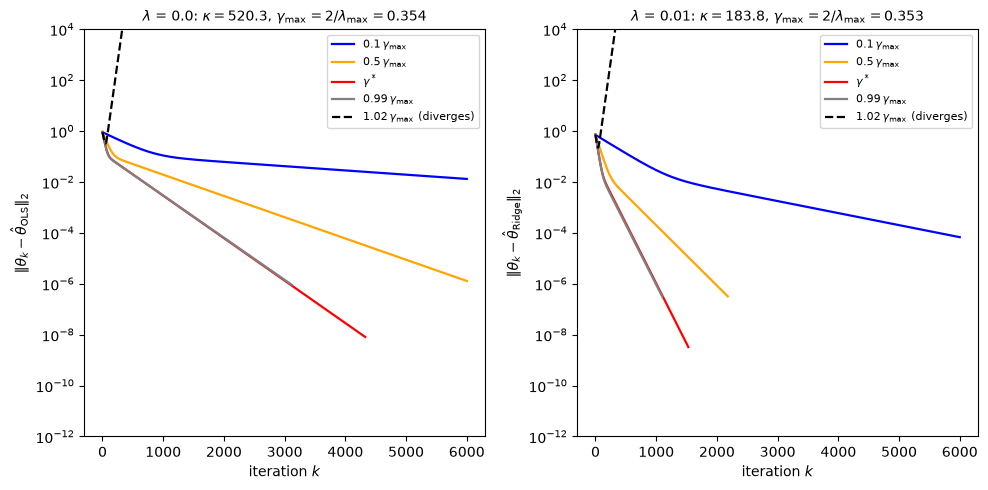

In [33]:
#Compare the gradient descent with the closed form solution for OLS and Ridge regression


# Functions from exercises
def cost(theta, X, y, lam=0.0):
    #if lambda == 0, this is OLS, otherwise Ridge
    return jnp.mean((y - X @ theta)**2) + lam * jnp.sum(theta**2)

def closed_form(X, y, lam=0.0):
    """Eq. (3.44) with the 1/n convention of Eq. (3.95): (X^T X + n lambda I)^-1 X^T y."""
    n, p = X.shape
    return np.linalg.solve(X.T @ X + n * lam * np.eye(p), X.T @ y)

def gradient(theta, X, y, lam=0.0):
    """Eqs. (4.13) and (4.17): the gradient of (1/n)||X theta - y||^2 + lambda theta^T theta."""
    n = len(y)
    return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta

def hessian_eigs(X, lam=0.0):
    """Eigenvalues of the Hessian (2/n) X^T X + 2 lambda I, Eqs. (4.14) and (4.17)."""
    n = len(X)
    return np.linalg.eigvalsh((2.0 / n) * X.T @ X + 2.0 * lam * np.eye(X.shape[1]))

#Gradient descent function
grad_jax = jax.grad(cost)
def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="analytical"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
        
    history = [theta0.copy()]

    # Gradient descent loop
    for t in range(1,num_iters+1):
        # Compute gradients for OLS / Ridge    

        if method == "analytical":
            # the gradients by hand (analytically)
            g = gradient(theta0, X, y, lmbda)
        elif method == "AD":
            # gradients by automatic differentiation (with respect to argument 0 = theta)
            g = grad_jax(theta0, X, y, lmbda)
        
        # Update parameters theta
        theta0 = theta0 - gamma * g

        history.append(theta0.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            print(f"Converged after {t} iterations.")
            break
    if t == num_iters:
            print("Reached maximum iterations without convergence.")

    return theta0, t, history



# def exercise_data2(n=100, degree=2, noise=0.5, seed=2026):
#     """Standardised polynomial design matrix (no intercept column) and centred targets."""
#     rng = np.random.default_rng(seed)
#     x = rng.uniform(-2.0, 2.0, n)
#     y = 2.0 - x + 5.0 * x**2 + noise * rng.standard_normal(n)
#     X = np.column_stack([x**k for k in range(1, degree + 1)])
#     X_mean, X_std = X.mean(axis=0), X.std(axis=0)
#     X_norm = (X - X_mean) / X_std
#     y_centered = y - y.mean()
#     return X_norm, y_centered


#Setting up the data for gradient descent
def exercise_data(n=100,sigma=0.1, seed=2026,degree=5):
    """Standardised polynomial design matrix (no intercept column) and centred targets."""
    x, y, n, sigma = generate_data()
    X = design_matrix(x, degree,intercept=False)

    X_mean, X_std = X.mean(axis=0), X.std(axis=0)
    X_norm = (X - X_mean) / X_std
    y_centered = y - y.mean()
    return X_norm, y_centered





#Function from tuesday week 37 exercise, tweaked to match the desired figures:
def fig_gd_convergence(filename="project1_gd_convergence.png"):

    fig, axes = plt.subplots(1,2, figsize=(10, 5))

    for ax, lam in zip(axes, lmbdas):
        #Getting the data and closed form solution for the given lambda:
        X,y = exercise_data(degree=degree)
        theta_cf = closed_form(X, y,lam=lam)
        #Getting the Hessian
        eigs = hessian_eigs(X,lam=lam)
        lmax, lmin = eigs.max(), eigs.min()
        #Finding optimal and maximum learning rates
        gamma_star, gamma_max = 2.0 / (lmax + lmin), 2.0 / lmax
        gammas = [0.1 * gamma_max, 0.5 * gamma_max, gamma_star, 0.99 * gamma_max, 1.02 * gamma_max] #Running with different gammas
        labels = [r"$0.1\,\gamma_{\max}$", r"$0.5\,\gamma_{\max}$", r"$\gamma^*$",
                    r"$0.99\,\gamma_{\max}$", r"$1.02\,\gamma_{\max}$ (diverges)"]
        colors = ["blue", "orange", "red", "grey", "black"]
        for gamma, lab, col in zip(gammas, labels, colors):
            
            #running the gradient descent
            theta_gd, t, history = gradient_descent(X,y,gamma,lam, num_iters, tol)
            #getting the distance to the closed form
            dist = np.linalg.norm(np.asarray(history) - theta_cf, axis=1)
            #plotting the results
            ax.semilogy(dist, color=col, label=lab, lw=1.6,
                        ls="--" if gamma > gamma_max else "-")
        ax.set_title(rf"$\lambda$ = {lam}: $\kappa={lmax/lmin:.1f}$, "
                        rf"$\gamma_{{\max}}=2/\lambda_{{\max}}={gamma_max:.3f}$", fontsize=10)
        ax.set_xlabel("iteration $k$")
        ax.set_ylim(1e-12, 1e4)
        ax.legend(fontsize=8, loc="upper right")
        if lam == 0.0: #Closed form for OLS
            ax.set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$")
        else: #Closed form for Ridge
            ax.set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{Ridge}}\|_2$")
    fig.tight_layout()
    fig.savefig(filename, bbox_inches="tight")
    plt.close(fig)



#Input data for gradient descent parameters:

# Learning rate gamma
gamma = 0.5
# The maximum number of iterations 
num_iters = 6000
# Tolerance for the stopping criterion
tol = 1e-8
# Lambda for regression (0 for OLS, >0 for Ridge)
lmbdas = [0.0, 1e-2]

X, y = exercise_data(degree=degree)
rng = np.random.default_rng(2026)

#Getting the Hessian eigenvalues and finding the condition number and maximum learning rate:
for lam in lmbdas:
    eigs = hessian_eigs(X,lam=lam)
    print(f"lambda = {lam}: lambda_max = {eigs.max():.4f}, lambda_min = {eigs.min():.4f}, "
            f"kappa = {eigs.max()/eigs.min():.1f}, gamma_max = {2/eigs.max():.4f}, "
            f"gamma* = {2/(eigs.max()+eigs.min()):.4f}")


# Plotting the convergence of gradient descent for different learning rates
with np.errstate(all="ignore"):
    fig_gd_convergence("project1_gd_convergence.png")
from IPython.display import Image

Image("project1_gd_convergence.png")


!! Study and compare your results from parts a) and b) with your gradient descent
approach: do you converge to the closed-form solutions, and how many iterations
does it take? Discuss in particular the role of the learning rate, and relate
the largest learning rate for which the iteration converges to the largest
eigenvalue of the Hessian matrix $\frac{2}{n}\boldsymbol{X}^T\boldsymbol{X}$
(plus $2\lambda\boldsymbol{I}$ for Ridge), see Section 4.5 of the lecture notes.


Answer: In this situation the learning rate is gamma = 0.5. Gamma max = 2/lambda_max = 0.354 (OLS). So the largest learing rate where it will converge is gamma max

Doing this analytically or by AD does not give different results (doublecheck this)

### Part f): Including momentum and more advanced ways to update the learning rate

We keep our focus on OLS and Ridge regression and update our gradient descent
code by including **momentum**, **AdaGrad**, **RMSprop** and **Adam** as methods
for iteratively updating the learning rate (Sections 4.6 and 4.8–4.11 of the
lecture notes; the lectures of weeks 37 and 38 contain several examples on how
to implement these methods). You are free to use either the analytical or the
automatically differentiated gradient here — the update rules do not care where
the gradient comes from.

Discuss the results and compare the different methods applied to the
one-dimensional Runge function, for example in terms of the number of iterations
needed to reach a given accuracy relative to the closed-form solution, and in
terms of their sensitivity to the choice of the (initial) learning rate.

<>:107: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:107: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\2120571672.py:107: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  ax.set_title("Initial learning rate $\gamma={:.2g}$".format(gamma), fontsize=10)
c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\numpy\linalg\_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
C:\Users\lukasjm\AppData\Local\Temp\ipykernel_26636\3439077642.py:17: RuntimeWarning: overflow encountered in matmul
  return (2.0 / n) * X.T @ (X @ theta - y) + 2.0 * lam * theta
C:\Users\lukasjm\AppData\Local\Temp\ipykern

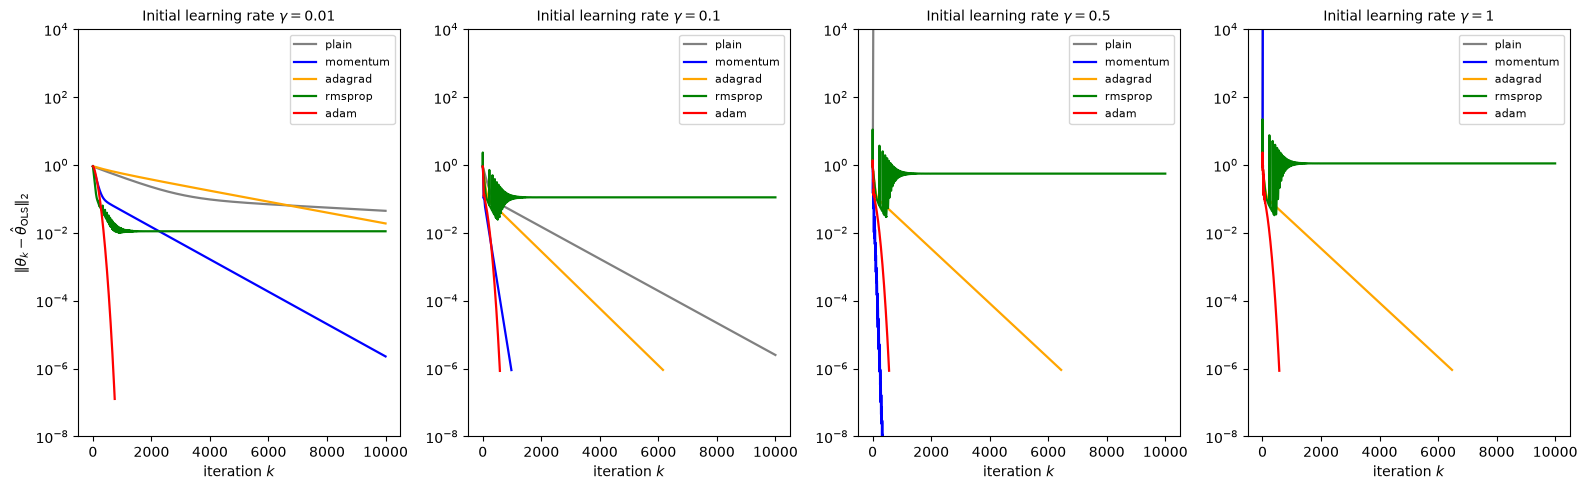

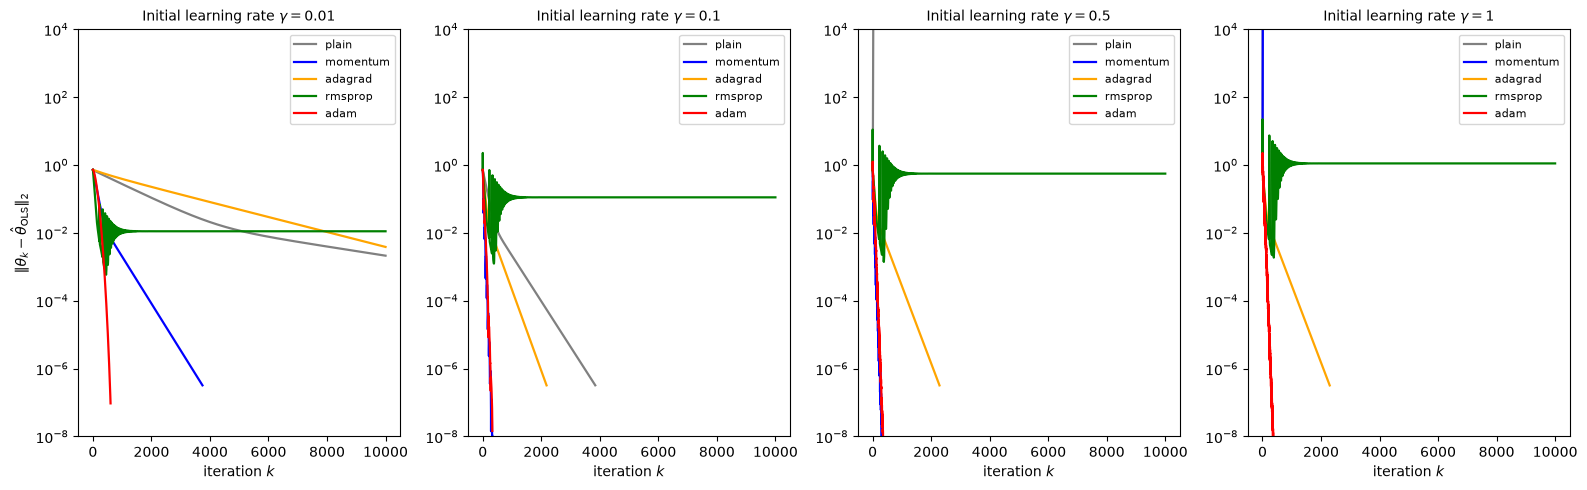

plain   : usable gamma from 0.0251 to 0.2512 ; best 840 iterations at gamma = 0.251
momentum: usable gamma from 0.0025 to 0.6310 ; best 110 iterations at gamma = 0.251
adagrad : usable gamma from 0.0158 to 1.0000 ; best 1130 iterations at gamma = 0.063
rmsprop : never reaches 1e-6 
adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025


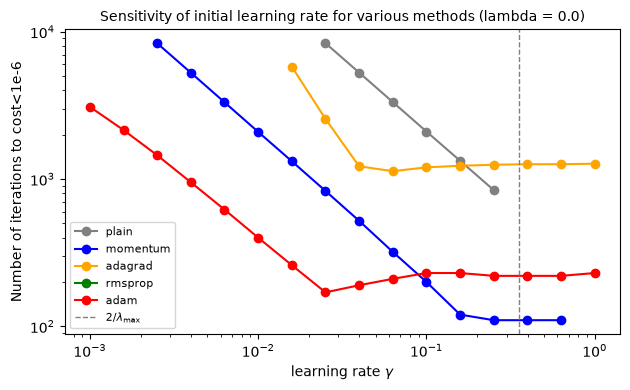

plain   : usable gamma from 0.0063 to 0.2512 ; best 250 iterations at gamma = 0.251
momentum: usable gamma from 0.0010 to 0.6310 ; best 100 iterations at gamma = 0.100
adagrad : usable gamma from 0.0100 to 1.0000 ; best 340 iterations at gamma = 0.100
rmsprop : usable gamma from 0.0025 to 1.0000 ; best 200 iterations at gamma = 0.010
adam    : usable gamma from 0.0010 to 1.0000 ; best 110 iterations at gamma = 0.063


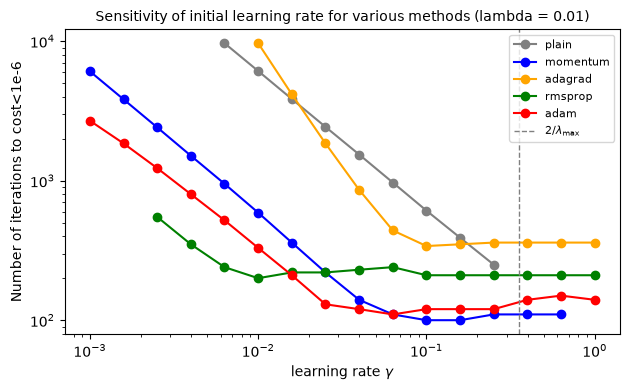

In [34]:
# Your code for part f) here

#Function from exercises
def optimiser_step(method, theta, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8):
    """One update of theta from the gradient g at step t (t = 1, 2, ...), Eqs. (4.10), (4.28),
    (4.42)-(4.45), (4.47)-(4.48) and (4.51)-(4.55).  state carries the running quantities."""
    if method == "plain":
        return theta - gamma * g, state
    if method == "momentum":
        v = beta * state.get("v", 0.0) + gamma * g               # Eq. (4.28)
        state["v"] = v
        return theta - v, state
    if method == "adagrad":
        r = state.get("r", 0.0) + g * g                           # Eq. (4.42)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.45)
    if method == "rmsprop":
        r = rho * state.get("r", 0.0) + (1.0 - rho) * g * g       # Eq. (4.47)
        state["r"] = r
        return theta - gamma * g / (np.sqrt(r) + eps), state      # Eq. (4.48)
    if method == "adam":
        m = beta1 * state.get("m", 0.0) + (1.0 - beta1) * g       # Eq. (4.51)
        r = beta2 * state.get("r", 0.0) + (1.0 - beta2) * g * g   # Eq. (4.52)
        state["m"], state["r"] = m, r
        m_hat = m / (1.0 - beta1**t)                              # Eq. (4.54)
        r_hat = r / (1.0 - beta2**t)
        return theta - gamma * m_hat / (np.sqrt(r_hat) + eps), state   # Eq. (4.55)
    raise ValueError(f"unknown method {method}")

   
#Updated gradient_descent function to include different methods
def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="plain"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
    
    history = [theta0.copy()]
    theta_an, state = np.array(theta0, dtype=float), {}

    # Gradient descent loop
    for t in range(1, num_iters+1):
        # Compute gradients for OLS / Ridge    

        # the gradients by hand (analytically)
        g = gradient(theta_an, X, y, lmbda)

        # Update parameters theta, depending on method:
        theta_an, state = optimiser_step(method, theta_an, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8)

        history.append(theta_an.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            break

    return theta_an, t, history

# ## Test data:
# def runge_data(n=100, degree=6, noise=0.1, seed=2026):
#     """Runge function 1/(1+25x^2) on [-1,1], standardised polynomial features, centred y."""
#     rng = np.random.default_rng(seed)
#     x = rng.uniform(-1.0, 1.0, n)
#     y = 1.0 / (1.0 + 25.0 * x**2) + noise * rng.standard_normal(n)
#     X = np.column_stack([x**k for k in range(1, degree + 1)])
#     X_norm = (X - X.mean(axis=0)) / X.std(axis=0)
#     return X_norm, y - y.mean()

# Xtest, ytest = runge_data(degree=6)
# theta_test = closed_form(Xtest, ytest)
# ccf_test = cost(theta_test, Xtest, ytest)
# grad_test = lambda th: gradient(th, Xtest, ytest)
# eigs_test = hessian_eigs(Xtest)
# ## end of test data


#input variables:
gammas = np.geomspace(1e-3, 1.0, 16)
num_iters = 10000
tol = 1e-8
methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
colors = ["gray", "blue", "orange", "green", "red"]
## end of input variables

X, y = exercise_data(degree=degree)

#Looping over both OLS and Ridge regression (lambda = 0.1)
for lmbda in lmbdas:
    theta_cf = closed_form(X, y, lam=lmbda)
    cost_cf = cost(theta_cf, X, y, lam=lmbda)
    grad_cf = gradient(theta_cf, X, y, lam=lmbda)
    eigs = hessian_eigs(X, lam=lmbda)
            
    #loop over different initial learning rates and methods
    fig, axes = plt.subplots(1,4,figsize=(16, 5))
    for ax, gamma in zip(axes, (0.01,0.1,0.5,1)): 

        for method, col in zip(methods, colors):
            
            theta_gd, t, history = gradient_descent(X, y, gamma, lmbda, num_iters, tol, method=method)
            #getting the distance to the closed form solution
            dist = np.linalg.norm(np.asarray(history) - theta_cf, axis=1)

            ax.semilogy(dist, color=col, label=method, lw=1.6)
        ax.set_title("Initial learning rate $\gamma={:.2g}$".format(gamma), fontsize=10)
        ax.set_xlabel("iteration $k$")
        ax.set_ylim(1e-8, 1e4)
        ax.legend(fontsize=8, loc="upper right")
    axes[0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$")
    fig.tight_layout()
    plt.show()




#Finding the best initial learning rate for each method
np.seterr(over="ignore", invalid="ignore")   # diverging runs overflow; that is the answer, not an error

for lmbda in lmbdas:
    theta_cf = closed_form(X, y, lam=lmbda)
    cost_cf = cost(theta_cf, X, y, lam=lmbda)
    grad_cf = gradient(theta_cf, X, y, lam=lmbda)
    eigs = hessian_eigs(X, lam=lmbda)

    scan = {}
    for method in methods:
        its = []
        for g in gammas:
            theta_gd, t, history = gradient_descent(X, y, g, lmbda=lmbda, num_iters=num_iters, tol=tol, method=method)

            e = np.array([cost(h, X, y,lam=lmbda) - cost_cf for h in history[::10]])

            its.append(int(np.argmax(e < 1e-6)) * 10 if (e < 1e-6).any() else None)
        scan[method] = its
        #Finding the usable and best gammas for each method:
        ok = [(gammas[i], its[i]) for i in range(len(its)) if its[i] is not None]
        best = min(ok, key=lambda t: t[1]) if ok else None
        print(f"{method:8s}: usable gamma from {ok[0][0]:.4f} to {ok[-1][0]:.4f}" if ok else f"{method:8s}: never reaches 1e-6",
            f"; best {best[1]} iterations at gamma = {best[0]:.3f}" if best else "")


    fig, ax = plt.subplots(figsize=(6.4, 4.0))

    for method, col in zip(methods, colors):
        its = np.array([np.nan if k is None else k for k in scan[method]])
        ax.loglog(gammas, its, "o-", color=col, label=method)
    ax.axvline(2 / eigs.max(), color="gray", ls="--", lw=1, label=r"$2/\lambda_{\max}$")
    ax.set_xlabel(r"learning rate $\gamma$"); ax.set_ylabel(r"iterations to excess cost $<10^{-6}$")
    ax.set_ylabel("Number of iterations to cost<1e-6")
    ax.set_title(f"Sensitivity of initial learning rate for various methods (lambda = {lmbda})", fontsize=10)
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()






#### !! Discuss the results and compare the different methods applied to theone-dimensional Runge function, for example in terms of the number of iterations needed to reach a given accuracy relative to the closed-form solution, and in terms of their sensitivity to the choice of the (initial) learning rate.



### Part g): Writing our own code for Lasso regression

Lasso regression (Section 3.9 of the lecture notes, and the lectures of weeks 35
and 36) represents our first encounter with a machine learning method which
cannot be solved through analytical expressions (as in OLS and Ridge
regression). Use the gradient descent methods you developed in parts e) and f)
to solve the Lasso optimization problem.

The $\ell_1$ penalty $\lambda\|\boldsymbol{\theta}\|_1$ is not differentiable
at $\theta_j=0$. Discuss how you could handle this: what does your automatic
differentiation tool return for the derivative of $|\theta|$ at zero, and is
that a valid subgradient? Based on the gradient, write your own code for Lasso
regression.

You can compare your results with the functionalities of **Scikit-Learn**; be
careful with the different conventions for the penalty parameter (`alpha`) and
the normalization of the cost function discussed in the week-35 and week-36
Tuesday sessions.

Discuss (critically) your results for the Runge function from OLS, Ridge and
Lasso regression using the various gradient descent approaches.

jax.grad(jnp.abs)(0.0) = 1.0
jax.grad(jnp.abs)(-0.3) = -1.0  jax.grad(jnp.abs)(0.3) = 1.0
own coordinate descent: [-0.60684   0.017896  0.402197  0.      ]
sklearn Lasso(alpha=lambda/2): [-0.60684   0.017896  0.402197  0.      ]
agree: True


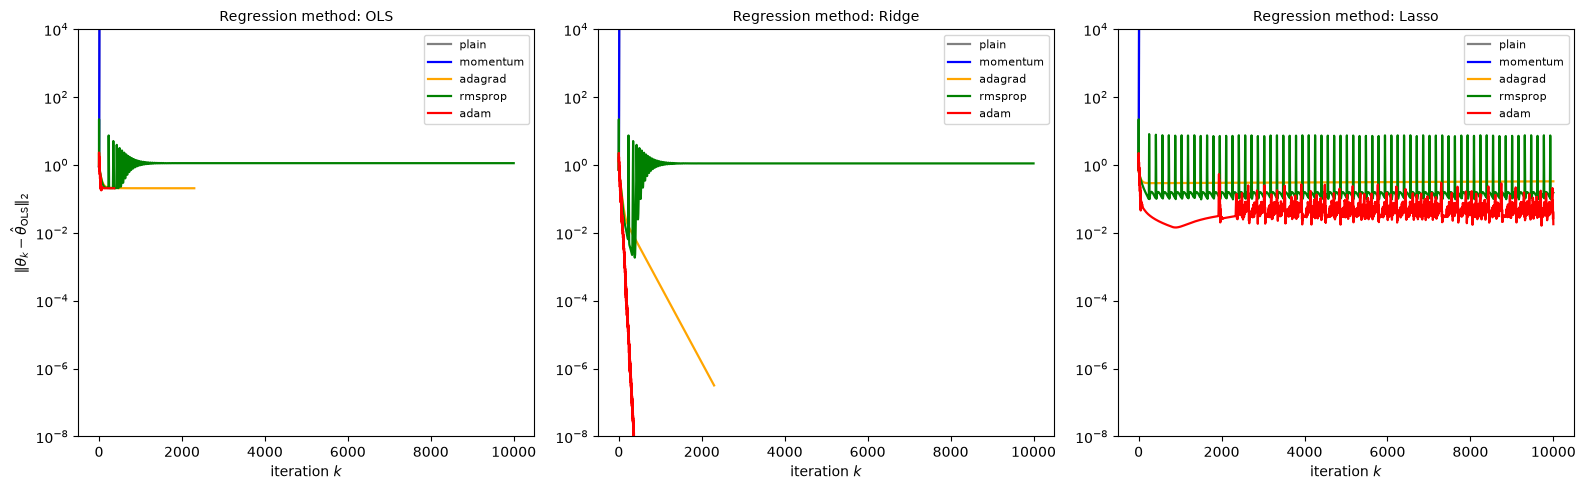

own coordinate descent: [ 0.01711  -0.599174  0.019461  0.393743 -0.006476]
sklearn Lasso(alpha=lambda/2): [ 0.015311 -0.603652  0.003994  0.39855   0.      ]
agree: False


In [35]:
# What does AD say about d|theta|/dtheta at theta = 0?  (Discuss whether this is a valid subgradient.)
print("jax.grad(jnp.abs)(0.0) =", jax.grad(jnp.abs)(0.0))
print("jax.grad(jnp.abs)(-0.3) =", jax.grad(jnp.abs)(-0.3), " jax.grad(jnp.abs)(0.3) =", jax.grad(jnp.abs)(0.3))

# Your Lasso code for part g) here
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#The problem is nonetheless convex – a sum of a convex quadratic and a convex norm
#  – so it has a global minimum and can be solved reliably; it is the closed form that is lost, not the solution.

yv = np.linspace(-3, 3, 11)


# 3. The Lasso convention. Our coordinate-descent solver with a soft threshold
#    minimises ||y - X theta||^2 / n + lambda ||theta||_1.
def soft_threshold(z, lmbda):
    return np.sign(z) * np.maximum(np.abs(z) - lmbda/2.0, 0.0) # Eq. (3.63)

def lasso_cd(X, y, lmbda, n_iter=10000, tol=1e-10):
    """Lasso by cyclic coordinate descent.
    The columns of X are assumed centred and standardised, 
    and no intercept is penalised 
    """
    n, p = X.shape
    theta = np.zeros(p)
    col_norms = np.sum(X**2, axis=0)
    r = y - X @ theta
    for _ in range(n_iter):
        theta_old = theta.copy()
        for j in range(p):
            r += X[:, j] * theta[j]
            theta[j] = soft_threshold(X[:, j] @ r, lmbda * n ) / col_norms[j]
            r -= X[:, j] * theta[j]
        if np.max(np.abs(theta - theta_old)) < tol:
            break
    return theta


# Standardised columns (Lasso needs comparable scales!)
Xs = (X[:, 1:] - X[:, 1:].mean(axis=0)) / X[:, 1:].std(axis=0)

theta_cd = lasso_cd(Xs, y, lmbda)
# our (1/n)||.||^2 + lambda||.||_1  equals  2 * ( (1/2n)||.||^2 + (lambda/2)||.||_1 )
theta_skl = Lasso(alpha=lmbda / 2.0, fit_intercept=False, max_iter=100000,
                  tol=1e-12).fit(Xs, y).coef_

print("own coordinate descent:", np.round(theta_cd, 6))
print("sklearn Lasso(alpha=lambda/2):", np.round(theta_skl, 6))
print("agree:", np.allclose(theta_cd, theta_skl, atol=1e-6))








   
#Updated gradient_descent function to include soft threshold for lasso

def gradient_descent(X,y,gamma,lmbda=0.0, num_iters=1000, tol=1e-8, method="plain",reg_method="lasso"):

    # Initialize weights for gradient descent
    n_features = X.shape[1]
    theta0 = np.zeros(n_features)
    
    history = [theta0.copy()]
    theta_an, state = np.array(theta0, dtype=float), {}

    # Gradient descent loop
    for t in range(1, num_iters+1):
        # Compute gradients for OLS / Ridge    

        # the gradients by hand (analytically)
        g = gradient(theta_an, X, y, lmbda)

        # Update parameters theta, depending on method:
        theta_an, state = optimiser_step(method, theta_an, g, state, t, gamma, beta=0.9, rho=0.99,
                   beta1=0.9, beta2=0.999, eps=1e-8)

        #soft threshold (if Lasso)
        if reg_method == "Lasso":
            theta_an = soft_threshold(theta_an, lmbda)

        history.append(theta_an.copy())
        
        # Stopping criterion:  gradient is small enough
        if np.linalg.norm(g) < tol:
            break

    return theta_an, t, history





methods = ["plain", "momentum", "adagrad", "rmsprop", "adam"]
colors = ["gray", "blue", "orange", "green", "red"]

fig, axes = plt.subplots(1,3,figsize=(16, 5))
for ax, reg_method in zip(axes, ("OLS","Ridge","Lasso")):

    if reg_method == "OLS":
        theta_ref = closed_form(X, y, 0.0)
    elif reg_method == "Ridge":
        theta_ref = closed_form(X, y, lmbda)
    else:
        theta_ref = Lasso(alpha=lmbda / 2.0, fit_intercept=False, max_iter=10000, # soft_threshold(Xtest[0,:], lmbda) #lasso_cd(Xtest, ytest, lmbda, n_iter=10000, tol=1e-10) #use soft threshold here instead of the closed form to account for the "0"
                  tol=1e-12).fit(X, y).coef_ 

    for method, col in zip(methods, colors):
        
        theta_gd, t, history = gradient_descent(X, y, gamma, lmbda, 10000, tol, method=method, reg_method=reg_method)

        dist = np.linalg.norm(np.asarray(history) - theta_ref, axis=1)

        ax.semilogy(dist, color=col, label=method, lw=1.6)
    ax.set_title(f"Regression method: {reg_method}", fontsize=10)
    ax.set_xlabel("iteration $k$")
    ax.set_ylim(1e-8, 1e4)
    # ax.set_xlim(1,200)
    ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel(r"$\|{\theta}_k-\hat{{\theta}}_{\mathrm{OLS}}\|_2$")
fig.tight_layout()
plt.show()


print("own coordinate descent:", np.round(theta_gd, 6))
print("sklearn Lasso(alpha=lambda/2):", np.round(theta_ref, 6))
print("agree:", np.allclose(theta_gd, theta_ref, atol=1e-6))







#### !! Answer on where theta = 0. : Optimality conditions, done properly.
Equation (3.59) was obtained by ignoring the point at which sgn is undefined. The difficulty is
removed rather than ignored by the subdifferential : for a convex function g, the subdifferen-
tial at a point is the set of slopes of all lines lying below the graph and touching it there, and
for the absolute value
∂ |θ | =



{+1} θ > 0,
{−1} θ < 0,
[−1, 1] θ = 0.
(3.65)
A convex function is minimised exactly where 0 belongs to its subdifferential, which is the
generalisation of “the derivative vanishes” and reduces to it wherever the function is differ-
entiable.

### Part h): Stochastic gradient descent

Our last gradient step is to include stochastic gradient descent (Section 4.7
of the lecture notes) using the same methods to update the learning rates as in
parts e)–g). Split the training data into mini-batches, loop over epochs, and
study the dependence on the mini-batch size, the number of epochs and the
learning-rate schedule. Compare and discuss your results with and without
stochastic gradient descent and give a critical assessment of the various
methods — both in terms of the final accuracy relative to the closed-form
solutions of parts a) and b), and in terms of computational cost.

full gradient: [-3.63576963  3.08698393 -3.71753913  3.23125842 -3.63438032]
Dependence of batch size M and epochs n_epochs and learning rate gamma on the distance to the closed-form solution (OLS_cf):


<>:87: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:93: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:93: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:93: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:93: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:93: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:117: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences wi

M = 1, gamma = 0.1: distance after 1 / 10 / 100 epochs 6.8e+01 / 8.8e+10 / 3.6e+102, min over the last 50 epochs 6.1e+51
M = 1, gamma = 0.02: distance after 1 / 10 / 100 epochs 7.8e-01 / 2.2e-01 / 2.0e-02, min over the last 50 epochs 2.0e-02
M = 5, gamma = 0.1: distance after 1 / 10 / 100 epochs 7.9e-01 / 2.4e-01 / 2.9e-02, min over the last 50 epochs 2.1e-02
M = 5, gamma = 0.02: distance after 1 / 10 / 100 epochs 8.8e-01 / 6.7e-01 / 9.9e-02, min over the last 50 epochs 9.9e-02
M = 25, gamma = 0.1: distance after 1 / 10 / 100 epochs 8.8e-01 / 6.7e-01 / 9.8e-02, min over the last 50 epochs 9.8e-02
M = 25, gamma = 0.02: distance after 1 / 10 / 100 epochs 9.1e-01 / 8.5e-01 / 5.0e-01, min over the last 50 epochs 5.0e-01


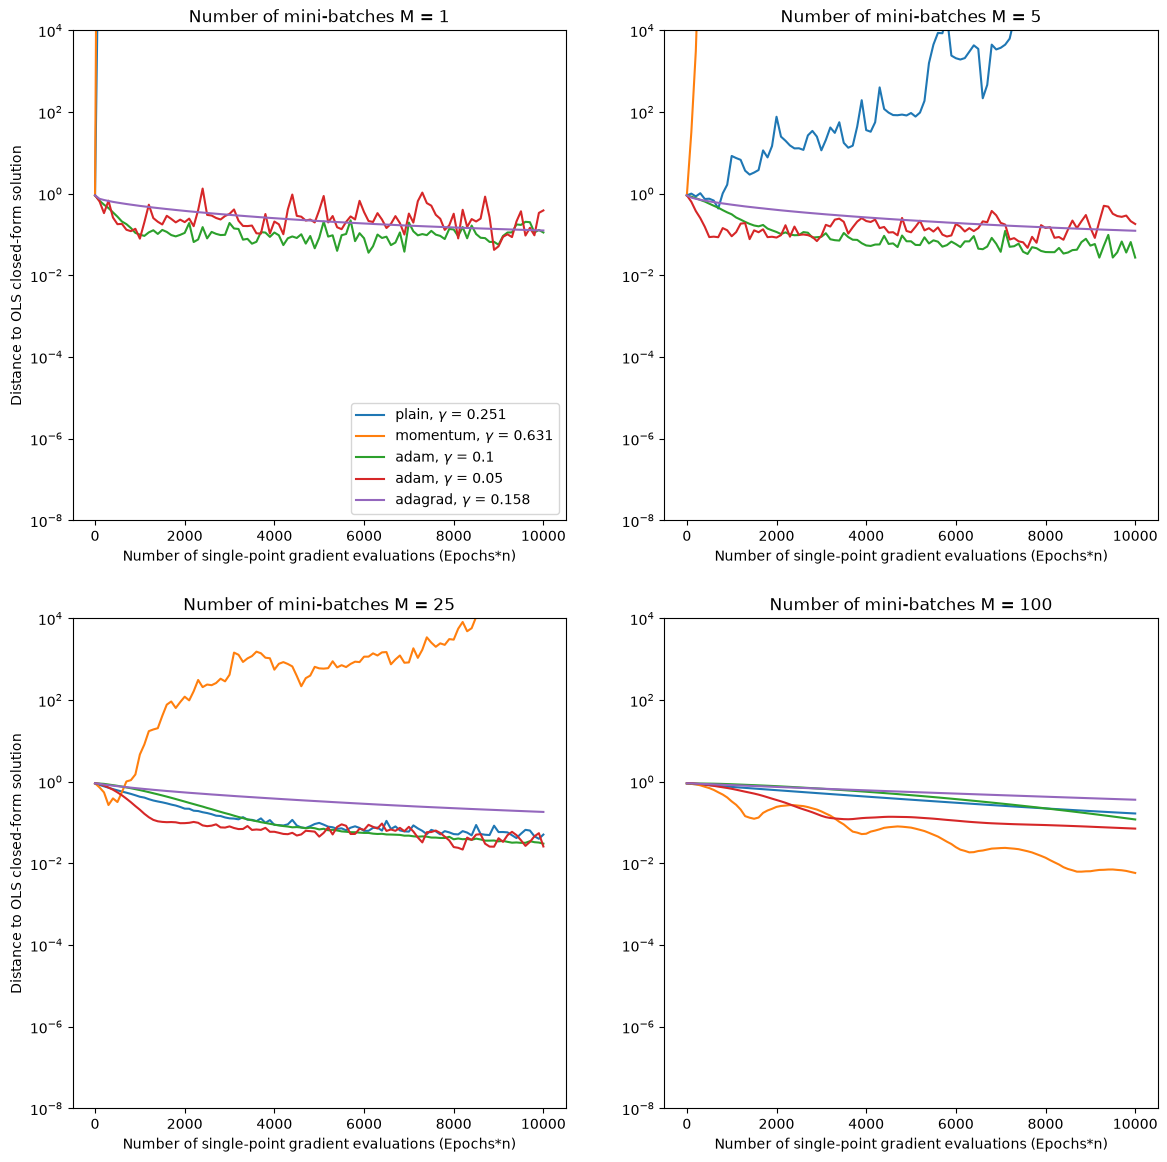

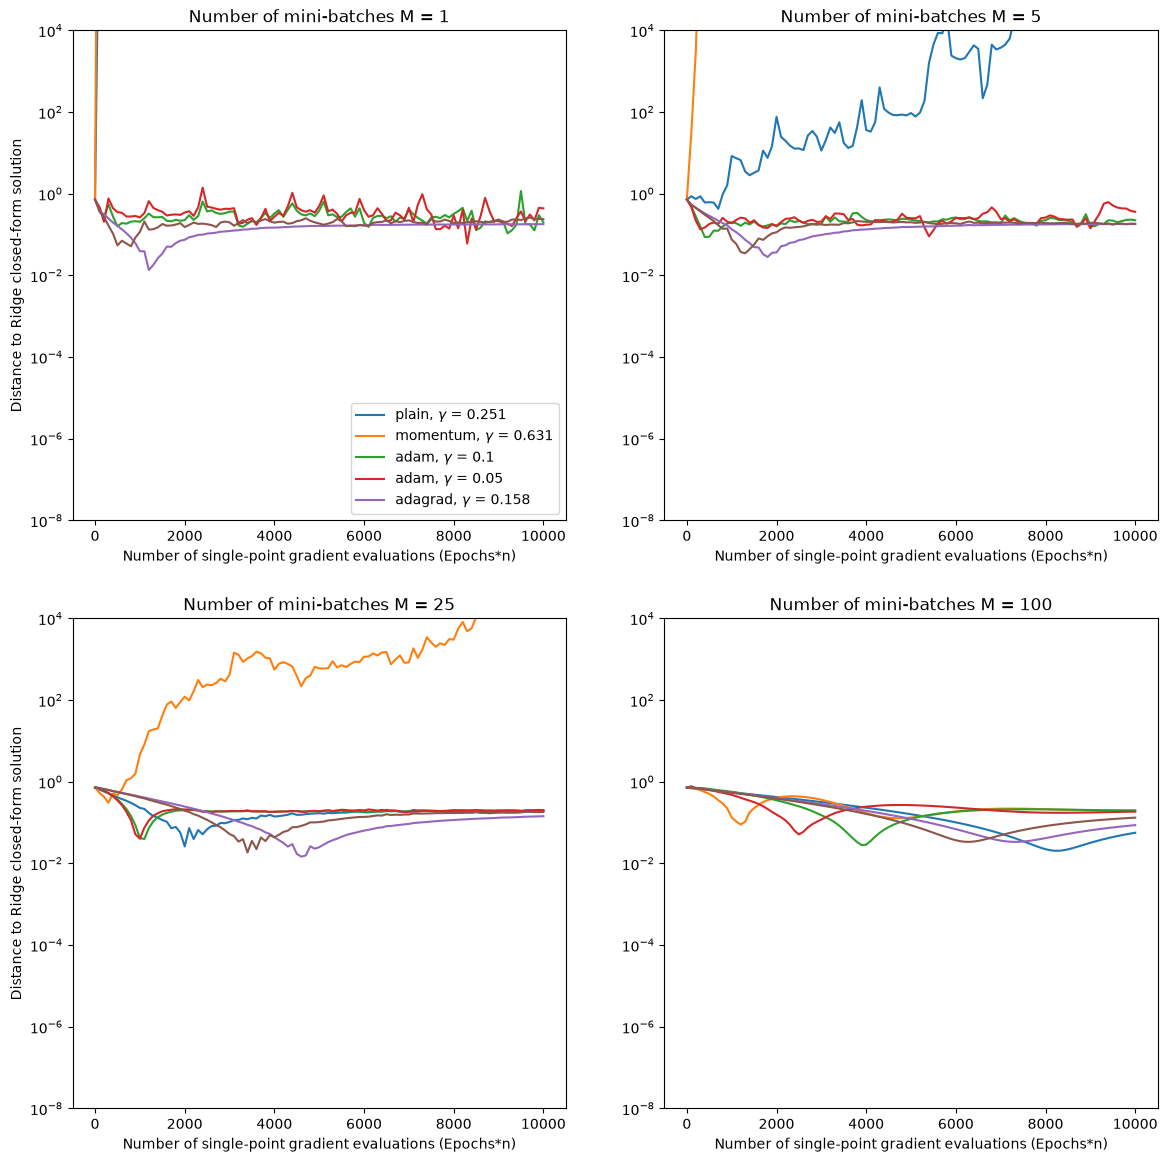

plain    gamma = 0.251: distance after 10 / 100 epochs 8.4e+00 / 1.9e+04
momentum gamma = 0.251: distance after 10 / 100 epochs 2.0e+23 / inf
adam     gamma = 0.063: distance after 10 / 100 epochs 2.0e-01 / 2.3e-01
adam     gamma = 0.1: distance after 10 / 100 epochs 1.9e-01 / 3.6e-01
rmsprop  gamma = 0.016: distance after 10 / 100 epochs 7.6e-02 / 1.8e-01


In [36]:
# Your code for part h) here
rng = np.random.default_rng(2026)

def make_batches(n, batch_size, rng):
    """Shuffle the indices and split them into minibatches (Section 4.7)."""
    idx = rng.permutation(n)
    return [idx[i:i + batch_size] for i in range(0, n, batch_size)]

def step_length(t, t0, t1):
    """The learning-rate schedule of Eq. (4.40)."""
    return t0 / (t + t1)


def sgd(X, y, method="plain", n_epochs=50, batch_size=5, gamma=0.1, schedule=None,
        lam=0.0, seed=2026, theta0=None, **kw):
    """Minibatch stochastic gradient descent, Eq. (4.34), with any optimiser of optimiser_step.
    schedule=(t0, t1) replaces the constant gamma by Eq. (4.40).  Returns the iterate after every epoch."""
    rng = np.random.default_rng(seed)
    n, p = X.shape
    theta = np.zeros(p) if theta0 is None else np.array(theta0, dtype=float)
    state, t, history = {}, 0, [theta.copy()]
    for epoch in range(n_epochs):
        for batch in make_batches(n, batch_size, rng):
            t += 1
            g = gradient(theta, X[batch], y[batch], lam)            # Eq. (4.33): the minibatch gradient
            g_t = gamma if schedule is None else step_length(t, *schedule)
            theta, state = optimiser_step(method, theta, g, state, t, g_t, **kw)
        history.append(theta.copy())
    return np.array(history)



X, y = exercise_data(degree=degree)
n = len(y)
theta_cf = closed_form(X, y)
# theta = np.zeros(X.shape[1])
theta = rng.normal(size=X.shape[1])
# theta = np.array([0.0, 3.0])
g_full = gradient(theta, X, y)
print("full gradient:", g_full)
rng = np.random.default_rng(2026)


#choose gamma based on f):
# OLS: 
# plain   : usable gamma from 0.0158 to 0.2512 ; best 840 iterations at gamma = 0.251
# momentum: usable gamma from 0.0016 to 0.6310 ; best 110 iterations at gamma = 0.251
# adagrad : usable gamma from 0.0100 to 1.0000 ; best 1130 iterations at gamma = 0.063
# rmsprop : never reaches 1e-6 
# adam    : usable gamma from 0.0010 to 1.0000 ; best 170 iterations at gamma = 0.025
#Dependence in batch size M, number of epochs n_epochs, and learning rate gamma
# Ridge (lambda = 0.1):
# plain   : usable gamma from 0.0010 to 0.2512 ; best 10 iterations at gamma = 0.251
# momentum: usable gamma from 0.0010 to 0.6310 ; best 10 iterations at gamma = 0.158
# adagrad : usable gamma from 0.0016 to 1.0000 ; best 10 iterations at gamma = 0.100
# rmsprop : usable gamma from 0.0010 to 1.0000 ; best 10 iterations at gamma = 0.010
# adam    : usable gamma from 0.0010 to 1.0000 ; best 20 iterations at gamma = 0.040
#Ridge (lambda = 0.01):
# plain   : usable gamma from 0.0010 to 0.2512 ; best 50 iterations at gamma = 0.251
# momentum: usable gamma from 0.0010 to 0.6310 ; best 10 iterations at gamma = 0.251
# adagrad : usable gamma from 0.0040 to 1.0000 ; best 50 iterations at gamma = 0.158
# rmsprop : usable gamma from 0.0010 to 1.0000 ; best 40 iterations at gamma = 0.016
# adam    : usable gamma from 0.0010 to 1.0000 ; best 30 iterations at gamma = 0.063


print("Dependence of batch size M and epochs n_epochs and learning rate gamma on the distance to the closed-form solution (OLS_cf):")
for M in (1, 5, 25):
    for gamma in (0.1, 0.02):
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        # print(f"M = {M:2d}: mean {np.round(gs.mean(axis=0), 3)}, spread {np.std(gs, axis=0).mean():.3f}")

        hist = sgd(X, y, n_epochs=100, batch_size=M, gamma=gamma)
        d = np.linalg.norm(hist - theta_cf, axis=1)
        print(f"M = {M}, gamma = {gamma}: distance after 1 / 10 / 100 epochs {d[1]:.1e} / {d[10]:.1e} / {d[100]:.1e}, "
            f"min over the last 50 epochs {d[50:].min():.1e}")

epochs = np.arange(0, 101)
fig, axes = plt.subplots(2,2,figsize=(14, 14))

for ax, M in zip(axes.flatten(), (1, 5, 25, n)): 
    for method, gamma in (("plain", 0.251), ("momentum", 0.251), ("adam", 0.025), ("adam", 0.1), ("adagrad", 0.063)): #also need to add RmSprop
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        
        hist = sgd(X, y, n_epochs=100, batch_size=M, gamma=gamma,method=method)
        d = np.linalg.norm(hist - theta_cf, axis=1)
        
        ax.semilogy(epochs*n,d,label=f"{method},$\gamma$ = {gamma}")

    
    ax.set_xlabel("Number of single-point gradient evaluations (Epochs*n)")
    ax.set_title("Number of mini-batches M = {}".format(M))
    ax.set_ylim(1e-8, 1e4)
axes[0,0].legend([f"plain, $\gamma$ = 0.251", f"momentum, $\gamma$ = 0.631", f"adam, $\gamma$ = 0.1", f"adam, $\gamma$ = 0.05", f"adagrad, $\gamma$ = 0.158"], loc="lower right")
axes[0,0].set_ylabel("Distance to OLS closed-form solution")
axes[1,0].set_ylabel("Distance to OLS closed-form solution")
plt.show()


# Ridge (lambda = 0.01):
# plain   : usable gamma from 0.0010 to 0.2512 ; best 50 iterations at gamma = 0.251
# momentum: usable gamma from 0.0010 to 0.6310 ; best 10 iterations at gamma = 0.251
# adagrad : usable gamma from 0.0040 to 1.0000 ; best 50 iterations at gamma = 0.158
# rmsprop : usable gamma from 0.0010 to 1.0000 ; best 40 iterations at gamma = 0.016
# adam    : usable gamma from 0.0010 to 1.0000 ; best 30 iterations at gamma = 0.063

theta_cf = closed_form(X, y,lam=lmbda)

fig, axes = plt.subplots(2,2,figsize=(14, 14))

for ax, M in zip(axes.flatten(), (1, 5, 25, n)): 
    for method, gamma in (("plain", 0.251), ("momentum", 0.251), ("adam", 0.063), ("adam", 0.1), ("adagrad", 0.158), ("rmsprop", 0.016)): #also need to add RmSprop
        gs = np.array([gradient(theta, X[b], y[b]) for _ in range(40) for b in make_batches(n, M, rng)])
        
        hist = sgd(X, y, n_epochs=100, batch_size=M, gamma=gamma,method=method)
        d = np.linalg.norm(hist - theta_cf, axis=1)
        
        ax.semilogy(epochs*n,d,label=f"{method},$\gamma$ = {gamma}")

    
    ax.set_xlabel("Number of single-point gradient evaluations (Epochs*n)")
    ax.set_title("Number of mini-batches M = {}".format(M))
    ax.set_ylim(1e-8, 1e4)
axes[0,0].legend([f"plain, $\gamma$ = 0.251", f"momentum, $\gamma$ = 0.631", f"adam, $\gamma$ = 0.1", f"adam, $\gamma$ = 0.05", f"adagrad, $\gamma$ = 0.158"], loc="lower right")
axes[0,0].set_ylabel("Distance to Ridge closed-form solution")
axes[1,0].set_ylabel("Distance to Ridge closed-form solution")
plt.show()




for method, gamma in (("plain", 0.251), ("momentum", 0.251), ("adam", 0.063), ("adam", 0.1), ("rmsprop", 0.016)):
    hist = sgd(X, y, n_epochs=100, batch_size=5, gamma=gamma, method=method)
    d = np.linalg.norm(hist - theta_cf, axis=1)
    print(f"{method:8s} gamma = {gamma}: distance after 10 / 100 epochs {d[10]:.1e} / {d[100]:.1e}")





### Part i): Final analysis — OLS, Ridge and Lasso with cross-validation

Bring the pieces together. Using the cross-validation setup from part d),
perform a final model selection for the Runge function with all three methods: OLS as a function of the polynomial
degree, and Ridge and Lasso as functions of both the polynomial degree and
$\lambda$. Present the results as a small number of well-chosen figures or
tables, identify the best model according to the cross-validated test error, and
discuss critically the strengths and weaknesses of the three methods for this
problem. Which of the terms in the bias-variance decomposition of part c) does
each method attack, and does your numerical evidence support that reading?

Comment: Does that mean we should do it for plain, momentum, adam, adagrad and rmsprop?

c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.457256e-03, tolerance: 7.908e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.580208e-03, tolerance: 8.727e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

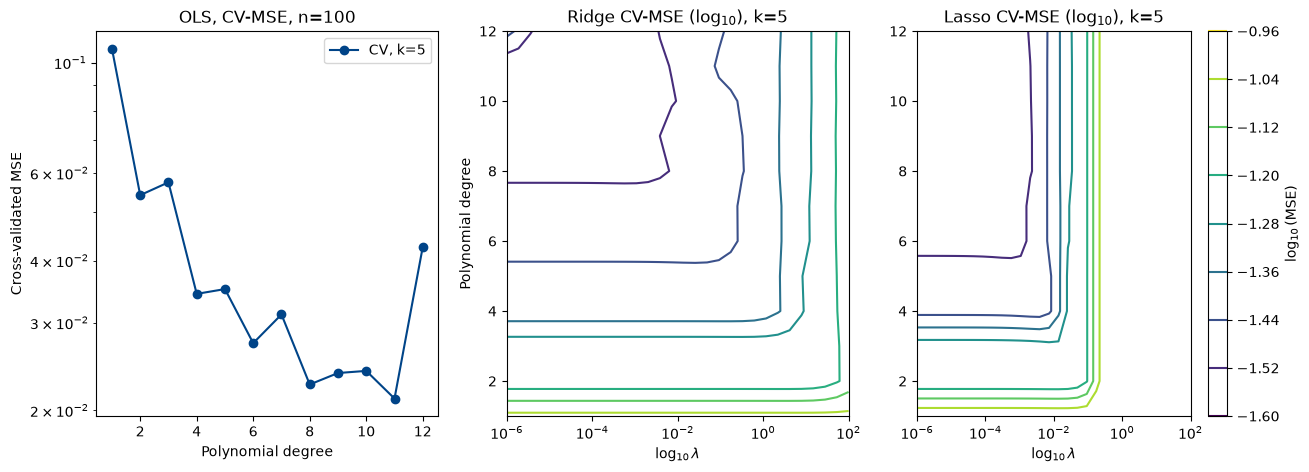

c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.457256e-03, tolerance: 7.908e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.580208e-03, tolerance: 8.727e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\lukasjm\AppData\Local\miniforge3\envs\lmk_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the 

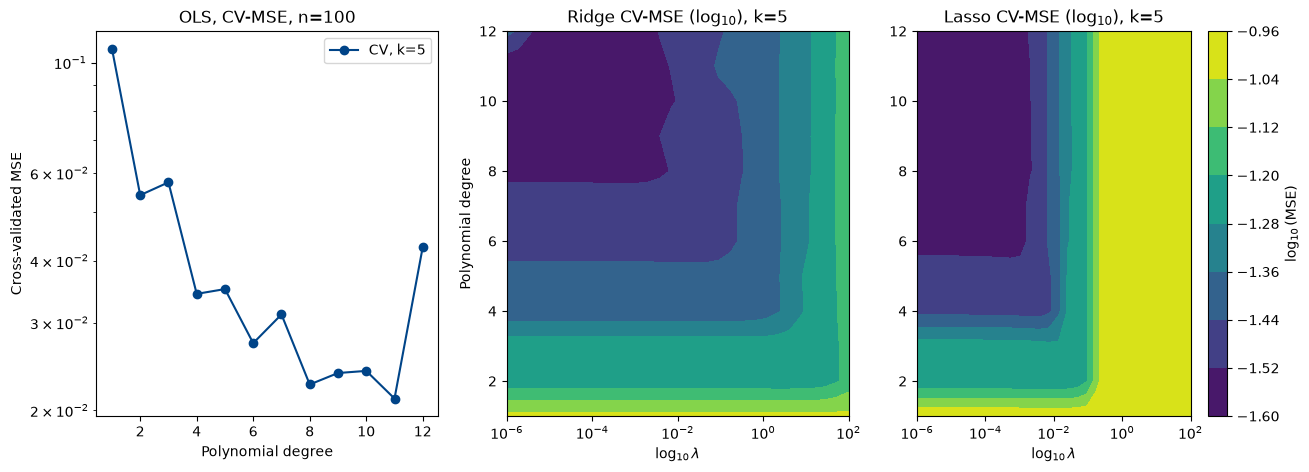

In [37]:
#CV MSE calculation for OLS regression

#similar to part d:
def cv_mse(x, y, degrees, lambdas, k, reg_method="OLS", seed=2026):
    """k-fold CV MSE for the three methods over a (degree, lambda) grid."""
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    if reg_method == "OLS":

        mse = np.zeros(len(degrees))
    
        for i, degree in enumerate(degrees):
            pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                LinearRegression(fit_intercept=False))
            scores = -cross_val_score(pipe, x, y, cv=kf,
                                    scoring="neg_mean_squared_error")
            mse[i] = scores.mean()
    else:
        mse = np.zeros((len(degrees), len(lambdas)))

        for i, degree in enumerate(degrees):
            for j, lmb in enumerate(lambdas):
                if reg_method == "Ridge":
                    pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                        StandardScaler(),
                                        Ridge(alpha=lmb))
                elif reg_method == "Lasso":
                    pipe = make_pipeline(PolynomialFeatures(degree=degree),
                                        StandardScaler(),
                                        Lasso(alpha=lmb))
                scores = -cross_val_score(pipe, x, y, cv=kf,
                                            scoring="neg_mean_squared_error")
                mse[i, j] = scores.mean()

    return mse



degrees = list(range(1, 13))
lambdas = np.logspace(-6, 2, 30)


fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse(x_cv, y_cv, degrees, lambdas, k=5, reg_method=reg_method)
    # mse_k10 = cv_mse(x_cv, y_cv, degrees, lambdas, k=10, reg_method=reg_method)

    if reg_method == "OLS":
        ax[i].plot(degrees, mse_k5,  "o-", color="#004488", label="CV, k=5")
        # ax[i].plot(degrees, mse_k10, "o-", color="#BB5566", label="CV, k=10")
        ax[i].set_yscale("log")
        ax[i].set_xlabel("Polynomial degree")
        ax[i].set_title(f"{reg_method}, CV-MSE, n={n}")
        ax[i].legend()
    else:
        # im = ax[i].imshow(np.log10(mse_k5), aspect="auto", origin="lower",
        #                     extent=[np.log10(lambdas[0]), np.log10(lambdas[-1]),
        #                             degrees[0], degrees[-1]])
        im = ax[i].contour(lambdas,degrees,np.log10(mse_k5), label="CV, k=5")
        ax[i].set_xscale("log")
        ax[i].set_xlabel(r"$\log_{10}\lambda$")
        ax[i].set_title(f"{reg_method} CV-MSE (log$_{{10}}$), k=5")
ax[1].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=ax[2], label=r"$\log_{10}$(MSE)")
ax[0].set_ylabel("Cross-validated MSE")
plt.show()


fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for i, reg_method in enumerate(("OLS", "Ridge", "Lasso")): 
    x_cv, y_cv, _, _ = generate_data(n=n, sigma=0.1, seed=2026)
    x_cv = x_cv.reshape(-1, 1)

    mse_k5  = cv_mse(x_cv, y_cv, degrees, lambdas, k=5, reg_method=reg_method)
    # mse_k10 = cv_mse(x_cv, y_cv, degrees, lambdas, k=10, reg_method=reg_method)

    if reg_method == "OLS":
        ax[i].plot(degrees, mse_k5,  "o-", color="#004488", label="CV, k=5")
        # ax[i].plot(degrees, mse_k10, "o-", color="#BB5566", label="CV, k=10")
        ax[i].set_yscale("log")
        ax[i].set_xlabel("Polynomial degree")
        ax[i].set_title(f"{reg_method}, CV-MSE, n={n}")
        ax[i].legend()
    else:

        im = ax[i].contourf(lambdas,degrees,np.log10(mse_k5), label="CV, k=5")
        ax[i].set_xscale("log")
        ax[i].set_xlabel(r"$\log_{10}\lambda$")
        ax[i].set_title(f"{reg_method} CV-MSE (log$_{{10}}$), k=5")
ax[1].set_ylabel("Polynomial degree")
fig.colorbar(im, ax=ax[2], label=r"$\log_{10}$(MSE)")
ax[0].set_ylabel("Cross-validated MSE")
plt.show()
